# 数据准备

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import load_from_disk
# 读取音频嵌入数据
embeddings_path = "/content/drive/MyDrive/yambda_500m/embeddings"
embeddings = load_from_disk(embeddings_path)

Loading dataset from disk:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
# 读取用户物品交互数据
multi_event_path = "/content/drive/MyDrive/yambda_500m/multi_event"
multi_event = load_from_disk(multi_event_path)

Loading dataset from disk:   0%|          | 0/29 [00:00<?, ?it/s]

In [ ]:
# 读取艺人专辑歌曲关系图
album_item_mapping_path = "/content/drive/MyDrive/yambda_500m/album_item_mapping"
album_item_mapping = load_from_disk(album_item_mapping_path)
artist_item_mapping_path = "/content/drive/MyDrive/yambda_500m/artist_item_mapping"
artist_item_mapping = load_from_disk(artist_item_mapping_path)

In [ ]:
import torch

print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 是否可用: {torch.cuda.is_available()}")

PyTorch 版本: 2.10.0+cu128
CUDA 是否可用: True


In [ ]:
# 🔥 开启 TF32 加速模式 (A100 显卡必备)
# 'high' 表示允许使用 TensorFloat32，精度略微下降但速度飞快
torch.set_float32_matmul_precision('high')

# 数据预处理和可视化分析

过滤数据，只保留用户收听时长大于歌曲时长的50%，且将歌曲标记为“喜欢”的交互行为

In [ ]:
import pandas as pd
import numpy as np
import torch
import time
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader

start_time = time.time()

print("🚀 第一步：极速加载数据到内存...")
# 只提取我们需要的列，避免加载无用数据
cols_to_keep = ['uid', 'item_id', 'timestamp', 'is_organic', 'event_type', 'played_ratio_pct']

# 利用底层的 PyArrow 引擎，瞬间转为 Pandas DataFrame
df = multi_event.select_columns(cols_to_keep).to_pandas()

print("🧹 第二步：正在进行高标准的数据清洗...")
# 瞬间填充空值为 0
df['played_ratio_pct'] = df['played_ratio_pct'].fillna(0.0)

# Pandas 向量化条件过滤，这在底层是 C 语言运行的，只需几秒钟
mask_like = df['event_type'] == 'like'
mask_listen = (df['event_type'] == 'listen') & (df['played_ratio_pct'] >= 50.0)

valid_mask = (mask_like | mask_listen)

total_raw = len(df)
# 应用掩码，保留干净数据
df_clean = df[valid_mask]
total_valid = len(df_clean)

# 修改后：保护长尾物品的单向过滤
print("🧹 正在进行【保留长尾】的高标准清洗...")

# 1. 物品端：极轻度过滤（比如只过滤掉全站只听过 1 次的绝对噪音，保留 >=2 的所有长尾）
min_item_inter = 2
item_counts = df_clean.groupby('item_id').size()
valid_i = item_counts[item_counts >= min_item_inter].index
df_clean = df_clean[df_clean['item_id'].isin(valid_i)]

# 2. 用户端：严格过滤（保证每个用户至少有 5 条记录，才能切分出 训练集/测试集）
min_user_inter = 5
user_counts = df_clean.groupby('uid').size()
valid_u = user_counts[user_counts >= min_user_inter].index
df_clean = df_clean[df_clean['uid'].isin(valid_u)]

print(f"   -> 原始交互总数: {total_raw}")
print(f"   -> 清洗后有效交互数: {total_valid} (剔除了 {total_raw - total_valid} 条无效交互)")

print("⏳ 第三步：提取纯 C 级底层数组并进行全局排序...")
# 直接提取 DataFrame 的 .values (底层就是连续的 NumPy C 数组)
uids = df_clean['uid'].values
item_ids = df_clean['item_id'].values
timestamps = df_clean['timestamp'].values

# 联合排序 (按 uid 排，uid 内部按 timestamp 排)
sort_idx = np.lexsort((timestamps, uids))
sorted_uids = uids[sort_idx]
sorted_items = item_ids[sort_idx]

print("⚡ 第四步：极速切分用户序列...")
# 核心加速魔法：利用 numpy 的 C 级数组切分
change_indices = np.where(sorted_uids[:-1] != sorted_uids[1:])[0] + 1
unique_uids = np.concatenate(([sorted_uids[0]], sorted_uids[change_indices]))
split_items = np.split(sorted_items, change_indices)

print("📦 第五步：正在组装用户序列字典...")
# 组装字典
user_seqs = {
    u.item(): items.tolist()
    for u, items in tqdm(zip(unique_uids, split_items), total=len(unique_uids), desc="组装进度", unit="user")
}

print(f"✅ 序列构建完成！总耗时: {time.time() - start_time:.2f} 秒\n")


🚀 第一步：极速加载数据到内存...
🧹 第二步：正在进行高标准的数据清洗...
🧹 正在进行【保留长尾】的高标准清洗...
   -> 原始交互总数: 480255564
   -> 清洗后有效交互数: 304024436 (剔除了 176231128 条无效交互)
⏳ 第三步：提取纯 C 级底层数组并进行全局排序...
⚡ 第四步：极速切分用户序列...
📦 第五步：正在组装用户序列字典...


组装进度: 100%|██████████| 98929/98929 [00:17<00:00, 5676.67user/s]

✅ 序列构建完成！总耗时: 257.62 秒



初步设想：通过用户最近50次的交互行为去预测下一次的交互行为

因此，接下来观察一下用户与物品的交互情况

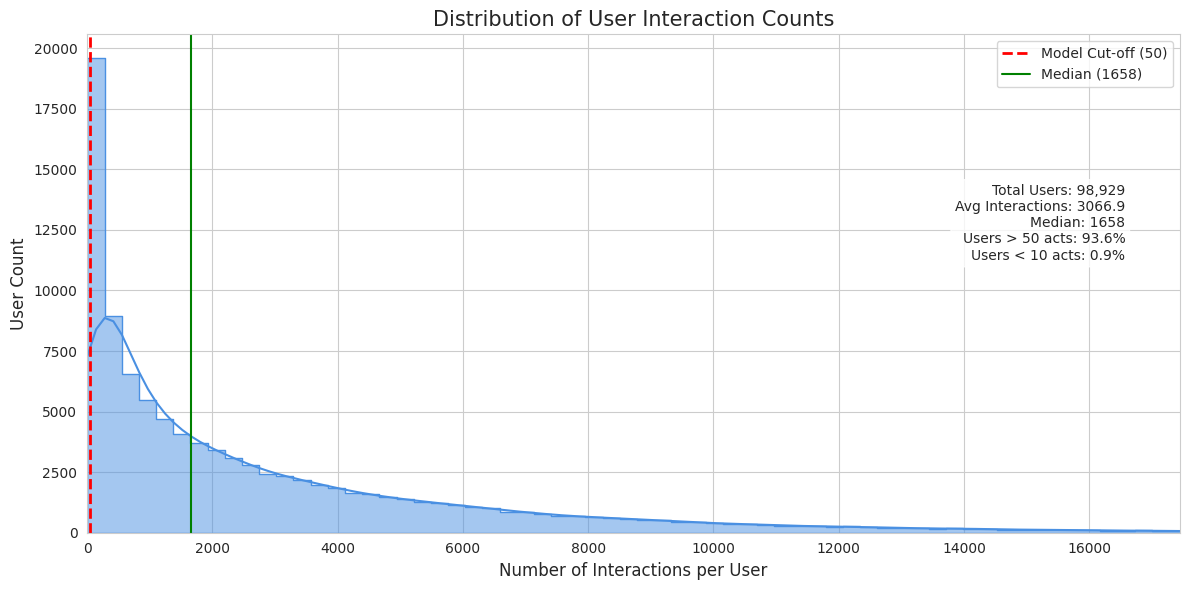

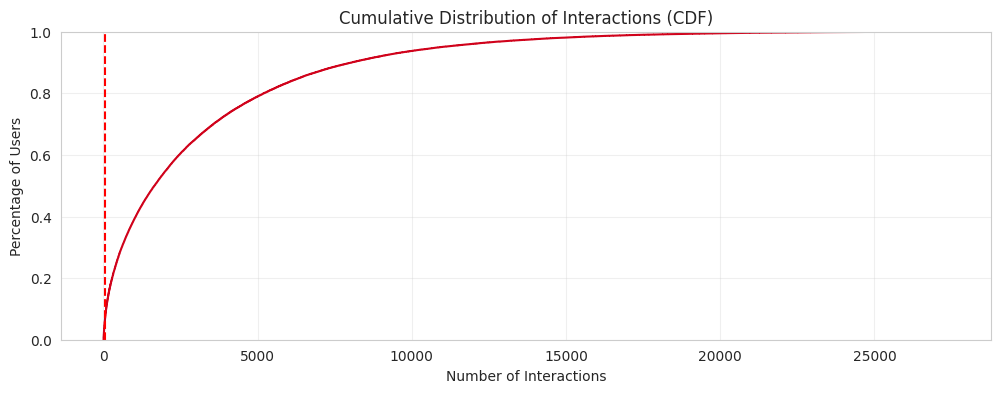

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 统计每个用户的交互序列长度
# 假设你已经运行了构建 user_seqs 的单元格
if 'user_seqs' in locals():
    # 提取所有用户的序列长度
    lengths = [len(seq) for seq in user_seqs.values()]
    lengths = np.array(lengths)

    # 2. 计算关键统计指标
    mean_len = np.mean(lengths)
    median_len = np.median(lengths)
    max_len_val = np.max(lengths)
    p90 = np.percentile(lengths, 90)

    # 超过 50 次和少于 10 次的比例
    over_50 = (lengths > 50).mean() * 100
    under_10 = (lengths < 10).mean() * 100

    # 3. 开始绘图
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    # 绘制直方图 (使用对数坐标以便看清长尾)
    sns.histplot(lengths, bins=100, kde=True, color='#4A90E2', element="step")

    # 添加截断基准线 (50次)
    plt.axvline(x=50, color='red', linestyle='--', linewidth=2, label=f'Model Cut-off (50)')
    plt.axvline(x=median_len, color='green', linestyle='-', linewidth=1.5, label=f'Median ({median_len:.0f})')

    # 修饰图表
    plt.title('Distribution of User Interaction Counts', fontsize=15)
    plt.xlabel('Number of Interactions per User', fontsize=12)
    plt.ylabel('User Count', fontsize=12)

    # 设置 X 轴范围（截取到 P99 左右，防止极个别超级活跃用户拉长坐标轴）
    plt.xlim(0, np.percentile(lengths, 99))

    # 添加信息文本框
    stats_text = (f"Total Users: {len(lengths):,}\n"
                  f"Avg Interactions: {mean_len:.1f}\n"
                  f"Median: {median_len:.0f}\n"
                  f"Users > 50 acts: {over_50:.1f}%\n"
                  f"Users < 10 acts: {under_10:.1f}%")
    plt.text(0.95, 0.7, stats_text, transform=plt.gca().transAxes,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4. 辅助观察：累积分布图 (CDF)
    plt.figure(figsize=(12, 4))
    sns.ecdfplot(lengths, color='#D0021B')
    plt.axvline(x=50, color='red', linestyle='--')
    plt.title('Cumulative Distribution of Interactions (CDF)')
    plt.xlabel('Number of Interactions')
    plt.ylabel('Percentage of Users')
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("❌ 请确保先运行了构建 user_seqs 的单元格！")

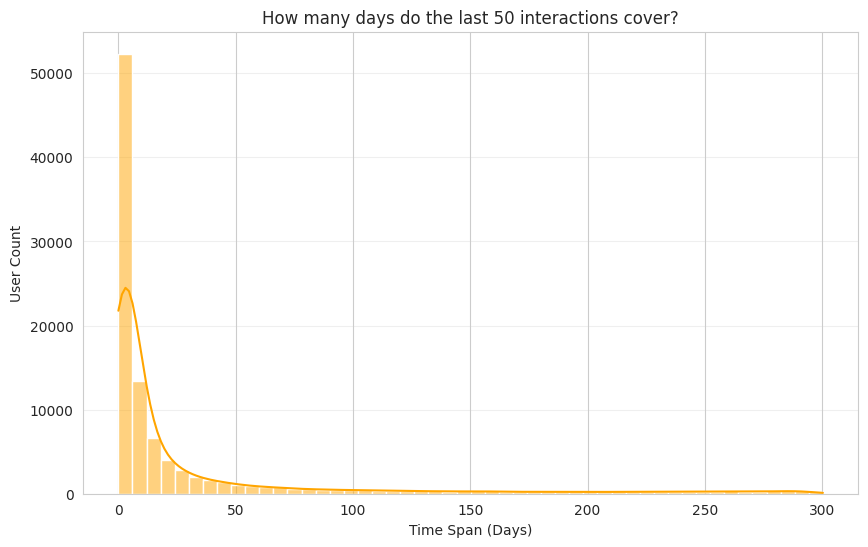

统计用户数: 98929
平均覆盖天数: 28.27 天
中位数: 5.17 天


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 对整个 DataFrame 按照 uid 和时间戳进行排序 (确保取出的是最后 50 次)
# 这一步是所有高效操作的基础
df_sorted = df_clean.sort_values(by=['uid', 'timestamp'])

# 2. 利用 groupby 和 tail(50) 瞬间获取每个用户最近的最多 50 次交互
# 这是 Pandas 的底层 C 实现，比循环快成千上万倍
recent_50 = df_sorted.groupby('uid').tail(50)

# 3. 再次利用聚合函数计算每个用户在这 50 次交互中的最大、最小时间戳以及交互次数
span_df = recent_50.groupby('uid')['timestamp'].agg(
    min_ts='min',
    max_ts='max',
    count='count'
)

# 4. 过滤掉交互次数少于 2 次的用户（对应你原代码的 if len(items) >= 2）
span_df = span_df[span_df['count'] >= 2].copy()

# 5. 计算时间跨度（天）
# 假设 timestamp 是以秒为单位的 Unix 时间戳
span_df['span_days'] = (span_df['max_ts'] - span_df['min_ts']) / (24 * 3600)
time_spans = span_df['span_days'].values

# 6. 绘图
plt.figure(figsize=(10, 6))
sns.histplot(time_spans, bins=50, kde=True, color='orange')
plt.title('How many days do the last 50 interactions cover?')
plt.xlabel('Time Span (Days)')
plt.ylabel('User Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 打印一下统计结果辅助分析
print(f"统计用户数: {len(time_spans)}")
print(f"平均覆盖天数: {time_spans.mean():.2f} 天")
print(f"中位数: {pd.Series(time_spans).median():.2f} 天")

通过上述分析可以发现，交互次数大于50的用户占绝大多数，最近50次交互的平均覆盖天数大约为28.35 天

In [ ]:
# ==========================================
# ✂️ 划分数据集与构建 PyTorch Dataset
# ==========================================
train_seqs, val_seqs, test_seqs = {}, {}, {}

for uid, seq in tqdm(user_seqs.items(), desc="划分数据集", unit="user"):
    if len(seq) < 3:
        continue
    train_seqs[uid] = seq[:-2]
    val_seqs[uid] = seq[:-1]
    test_seqs[uid] = seq

print(f"\n✅ 有效训练用户数: {len(train_seqs)}")

class SequenceDataset(Dataset):
    def __init__(self, user_seqs, max_len=50):
        self.uids = list(user_seqs.keys())
        self.seqs = [user_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        seq = seq[-self.max_len-1:]

        pad_len = self.max_len + 1 - len(seq)
        seq = [0] * pad_len + seq

        x = torch.tensor(seq[:-1], dtype=torch.long)
        y = torch.tensor(seq[1:], dtype=torch.long)
        return x, y

MAX_SEQ_LEN = 50
train_dataset = SequenceDataset(train_seqs, max_len=MAX_SEQ_LEN)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

划分数据集: 100%|██████████| 98929/98929 [00:11<00:00, 8445.72user/s]


✅ 有效训练用户数: 98929


In [ ]:
print("🚀 正在构建全局对齐的声学特征矩阵...")
start_emb_time = time.time()

# 1. 将 embeddings 数据集极速转为 Pandas DataFrame
df_emb = embeddings.select_columns(['item_id', 'embed']).to_pandas()

# 2. 找到全局最大的 item_id，以确定我们需要多大的词表 (Vocabulary Size)
# 确保矩阵的行数足够容纳所有的 item_id
max_item_id = max(df_clean['item_id'].max(), df_emb['item_id'].max())
feature_dim = len(df_emb.iloc[0]['embed'])

# 3. 初始化全 0 矩阵 (行数为 max_item_id + 1，第 0 行自然被保留为 0 用于 Padding)
track_vectors = np.zeros((max_item_id + 1, feature_dim), dtype=np.float32)

# 4. 利用 NumPy 的高级索引 (Advanced Indexing) 瞬间将特征填入对应行
# df_emb['item_id'].values 作为行索引，精准对齐
track_vectors[df_emb['item_id'].values] = np.vstack(df_emb['embed'].values)

num_tracks = max_item_id # 这将是我们传入模型的物品总量

print(f"✅ 特征矩阵构建完成！")
print(f"   -> 矩阵形状: {track_vectors.shape} (行数=词表大小+1, 列数=特征维度)")
print(f"   -> 总耗时: {time.time() - start_emb_time:.2f} 秒\n")

🚀 正在构建全局对齐的声学特征矩阵...
✅ 特征矩阵构建完成！
   -> 矩阵形状: (9390624, 128) (行数=词表大小+1, 列数=特征维度)
   -> 总耗时: 66.55 秒



# 定义验证集与验证函数

In [ ]:
# ==========================================
# 0. 补全缺失的验证集定义 (解决 NameError)
# ==========================================
from torch.utils.data import Dataset, DataLoader

class ValSequenceDataset(Dataset):
    def __init__(self, val_seqs, max_len=50):
        self.uids = list(val_seqs.keys())
        self.seqs = [val_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        # 验证集：用倒数第二首 (target) 之前的序列 (hist) 进行预测
        target = seq[-1]
        hist = seq[:-1]

        hist = hist[-self.max_len:]
        pad_len = self.max_len - len(hist)
        hist = [0] * pad_len + hist

        return torch.tensor(hist, dtype=torch.long), torch.tensor(target, dtype=torch.long)

# 确保 MAX_SEQ_LEN 已经定义（之前我们设为 50）
if 'MAX_SEQ_LEN' not in locals():
    MAX_SEQ_LEN = 50

# 创建验证集加载器
val_dataset = ValSequenceDataset(val_seqs, max_len=MAX_SEQ_LEN)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

print("✅ val_loader 已成功定义！现在可以重新运行训练单元格了。")

✅ val_loader 已成功定义！现在可以重新运行训练单元格了。


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score # 🌟 补上这个关键导入

@torch.no_grad()
def evaluate_auc_pro(model, val_loader, num_items, device):
    model.eval()
    all_targets, all_preds = [], []

    for x, target in val_loader:
        x, target = x.to(device), target.to(device)

        # 强制使用 float32 避免半精度带来的数值不稳定
        fused_out = model(x).float()
        last_step_state = fused_out[:, -1, :]

        # 计算正样本得分 (L2 归一化后的点积)
        pos_embs = model.get_item_representation(target).float()
        pos_scores = (last_step_state * pos_embs).sum(dim=-1, keepdim=True)

        # 负样本随机采样 99 个
        negatives = torch.randint(1, num_items + 1, (x.size(0), 99), device=device)
        neg_embs = model.get_item_representation(negatives).float()
        neg_scores = (last_step_state.unsqueeze(1) * neg_embs).sum(dim=-1)

        # 转换为 numpy 并清除 NaN (双重保险)
        scores = torch.cat([pos_scores, neg_scores], dim=1).view(-1).cpu().numpy()
        scores = np.nan_to_num(scores, nan=0.0)

        all_preds.append(scores)
        all_targets.append(torch.cat([torch.ones_like(pos_scores), torch.zeros_like(neg_scores)], dim=1).view(-1).cpu().numpy())

    # 计算全局 AUC
    y_true = np.concatenate(all_targets)
    y_score = np.concatenate(all_preds)

    return roc_auc_score(y_true, y_score)

print("✅ 所有库已导入，验证函数 evaluate_auc_pro 已准备就绪！")

✅ 所有库已导入，验证函数 evaluate_auc_pro 已准备就绪！


# 图序列混合网络 (Graph-Sequence Fusion)

## 模型定义

### 图序列混合网络修订说明

本版本按以下原则改造 `FDSA_Graph_Fusion`：

1. **共享融合头（shared fusion head）**：sequence 侧与 item 侧统一使用同一个 `SharedGatedFusion` 模块，避免 `forward()` 与 `get_item_representation()` 落在不同表示空间。
2. **门控融合（gated fusion）**：自动学习 ID / acoustic / graph 三个模态的权重，而不是简单相加。
3. **独立三流编码器**：ID、音频、图结构各自保留独立 Transformer encoder，避免不同模态被迫共享同一统计结构。
4. **接口保持兼容**：训练、验证、评测代码仍然可以直接复用 `model_graph(x)` 与 `model_graph.get_item_representation(...)`。


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F


class SharedGatedFusion(nn.Module):
    """共享门控融合头：sequence 侧与 item 侧共用同一套参数。"""

    def __init__(self, hidden_dim, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gate = nn.Linear(hidden_dim * 3, 3)
        self.proj = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_dim)

    def compute_gate(self, x_id, x_acoustic, x_graph):
        concat = torch.cat([x_id, x_acoustic, x_graph], dim=-1)
        gate = torch.softmax(self.gate(concat), dim=-1)
        return gate

    def forward(self, x_id, x_acoustic, x_graph, return_gate=False):
        # 允许输入形状为 [B, L, D] 或 [N, D]
        gate = self.compute_gate(x_id, x_acoustic, x_graph)

        fused = (
            gate[..., 0:1] * x_id
            + gate[..., 1:2] * x_acoustic
            + gate[..., 2:3] * x_graph
        )
        fused = self.proj(fused)
        fused = self.dropout(torch.relu(fused))
        fused = self.norm(fused)
        fused = F.normalize(fused, p=2, dim=-1, eps=1e-8)
        if return_gate:
            return fused, gate
        return fused


class FDSA_Graph_Fusion(nn.Module):
    def __init__(self, num_items, item_dim=64, acoustic_dim=128, graph_dim=64,
                 pretrained_acoustic=None, pretrained_graph=None,
                 max_seq_len=50, num_heads=4, num_layers=2, dropout=0.2):
        super(FDSA_Graph_Fusion, self).__init__()
        self.max_seq_len = max_seq_len
        self.item_dim = item_dim
        self.num_items = num_items

        # ==========================================
        # 1. 三大底层 Embedding 层
        # ==========================================
        self.item_emb = nn.Embedding(num_items + 1, item_dim, padding_idx=0)

        self.acoustic_emb = nn.Embedding(num_items + 1, acoustic_dim, padding_idx=0)
        self.graph_emb = nn.Embedding(num_items + 1, graph_dim, padding_idx=0)

        self._load_pretrained_embedding(self.acoustic_emb, pretrained_acoustic, acoustic_dim, 'acoustic')
        self._load_pretrained_embedding(self.graph_emb, pretrained_graph, graph_dim, 'graph')

        # 统一维度投影
        self.acoustic_proj = nn.Linear(acoustic_dim, item_dim)
        self.graph_proj = nn.Linear(graph_dim, item_dim)
        self.pos_emb = nn.Embedding(max_seq_len, item_dim)
        self.dropout = nn.Dropout(dropout)

        # ==========================================
        # 2. 三流独立 Transformer Encoders
        # ==========================================
        self.id_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=item_dim,
                nhead=num_heads,
                dim_feedforward=item_dim * 4,
                dropout=dropout,
                batch_first=True,
            ),
            num_layers=num_layers,
        )
        self.acoustic_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=item_dim,
                nhead=num_heads,
                dim_feedforward=item_dim * 4,
                dropout=dropout,
                batch_first=True,
            ),
            num_layers=num_layers,
        )
        self.graph_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=item_dim,
                nhead=num_heads,
                dim_feedforward=item_dim * 4,
                dropout=dropout,
                batch_first=True,
            ),
            num_layers=num_layers,
        )

        # ==========================================
        # 3. 共享融合头（关键改动）
        # ==========================================
        self.fusion = SharedGatedFusion(hidden_dim=item_dim, dropout=dropout)

    def _load_pretrained_embedding(self, emb_layer, pretrained_matrix, expected_dim, name):
        if pretrained_matrix is None:
            return

        weight = torch.tensor(pretrained_matrix, dtype=torch.float32)
        if weight.ndim != 2 or weight.size(1) != expected_dim:
            raise ValueError(
                f"{name} pretrained matrix shape mismatch: expected (*, {expected_dim}), got {tuple(weight.shape)}"
            )

        # 兼容两种输入：
        # 1) [num_items + 1, dim]（已含 padding 行）
        # 2) [num_items, dim]     （不含 padding 行，需要前面补零）
        if weight.size(0) == self.num_items + 1:
            emb_layer.weight.data.copy_(weight)
        elif weight.size(0) == self.num_items:
            padded = torch.zeros(self.num_items + 1, expected_dim, dtype=torch.float32)
            padded[1:] = weight
            emb_layer.weight.data.copy_(padded)
        else:
            raise ValueError(
                f"{name} pretrained matrix row mismatch: expected {self.num_items} or {self.num_items + 1}, got {weight.size(0)}"
            )
        emb_layer.weight.requires_grad = True

    def _build_masks(self, seqs):
        device = seqs.device
        _, seq_len = seqs.size()
        padding_mask = (seqs == 0)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len, device=device).bool()
        return padding_mask, causal_mask

    def _add_position(self, x):
        batch_size, seq_len, _ = x.size()
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        return x + self.pos_emb(positions)

    def get_item_modalities(self, item_ids):
        e_id = self.item_emb(item_ids)
        e_acoustic = self.acoustic_proj(self.acoustic_emb(item_ids))
        e_graph = self.graph_proj(self.graph_emb(item_ids))
        return e_id, e_acoustic, e_graph

    def encode_modalities(self, seqs):
        """
        返回上下文化后的三路表示：
        z_id, z_acoustic, z_graph: [B, L, D]
        """
        padding_mask, causal_mask = self._build_masks(seqs)

        # 三路基础表示
        e_id, e_acoustic, e_graph = self.get_item_modalities(seqs)

        # 加位置编码
        id_embs = self._add_position(e_id)
        acoustic_embs = self._add_position(e_acoustic)
        graph_embs = self._add_position(e_graph)

        # 三流独立上下文化
        id_out = self.id_encoder(
            self.dropout(id_embs),
            mask=causal_mask,
            src_key_padding_mask=padding_mask,
        )
        acoustic_out = self.acoustic_encoder(
            self.dropout(acoustic_embs),
            mask=causal_mask,
            src_key_padding_mask=padding_mask,
        )
        graph_out = self.graph_encoder(
            self.dropout(graph_embs),
            mask=causal_mask,
            src_key_padding_mask=padding_mask,
        )
        return id_out, acoustic_out, graph_out

    def forward(self, seqs, return_gate=False):
        """序列编码：输出归一化后的隐状态 [B, L, D]。"""
        id_out, acoustic_out, graph_out = self.encode_modalities(seqs)
        if return_gate:
            fused_out, gate = self.fusion(id_out, acoustic_out, graph_out, return_gate=True)
            return fused_out, gate
        return self.fusion(id_out, acoustic_out, graph_out, return_gate=False)

    def get_item_representation(self, item_ids, return_gate=False):
        """物品综合编码：与 sequence 侧共享同一套融合逻辑。"""
        e_id, e_acoustic, e_graph = self.get_item_modalities(item_ids)
        if return_gate:
            rep, gate = self.fusion(e_id, e_acoustic, e_graph, return_gate=True)
            return rep, gate
        return self.fusion(e_id, e_acoustic, e_graph, return_gate=False)

    def get_last_step_gate(self, seqs):
        """
        返回最后一步的 gate 权重，便于可视化：
        gates: [B, 3]，三列分别是 [ID_gate, Acoustic_gate, Graph_gate]
        """
        _, gate = self.forward(seqs, return_gate=True)
        return gate[:, -1, :]


In [ ]:
import torch
import numpy as np
import pandas as pd
import scipy.sparse as sp
import time

print("🌌 准备进行极速异构图消息传递 (LightGCN-style)...")
start_g_time = time.time()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 1. 将 Mapping 数据转为 Pandas (极速提取边)
# ==========================================
df_artist = artist_item_mapping.to_pandas()
df_album = album_item_mapping.to_pandas()

num_items = num_tracks # 复用之前的总量

# 找出艺人和专辑的最大 ID 以确定矩阵形状
num_artists = df_artist['artist_id'].max()
num_albums = df_album['album_id'].max()

# ==========================================
# 2. 核心魔法函数：构建双向对称归一化稀疏矩阵 D^{-1/2} M D^{-1/2}
# ==========================================
def build_normalized_bipartite_matrix(df, item_col, entity_col, n_items, n_entities):
    items = df[item_col].values
    entities = df[entity_col].values
    data = np.ones(len(items), dtype=np.float32)

    # 构建基础的稀疏共现矩阵 M (Item x Entity)
    M = sp.coo_matrix((data, (items, entities)), shape=(n_items + 1, n_entities + 1))

    # 计算度数 (Degree)
    item_degree = np.array(M.sum(axis=1)).flatten()
    entity_degree = np.array(M.sum(axis=0)).flatten()

    # D^{-1/2}
    d_inv_item = np.power(item_degree, -0.5, where=item_degree > 0)
    d_inv_item[item_degree == 0] = 0.0
    d_inv_entity = np.power(entity_degree, -0.5, where=entity_degree > 0)
    d_inv_entity[entity_degree == 0] = 0.0

    # 矩阵缩放: D_item * M * D_entity
    D_item = sp.diags(d_inv_item)
    D_entity = sp.diags(d_inv_entity)
    M_norm = D_item.dot(M).dot(D_entity).tocoo()

    # 转为 PyTorch GPU 稀疏张量 (极速相乘的底座)
    indices = torch.tensor(np.vstack((M_norm.row, M_norm.col)), dtype=torch.long)
    values = torch.tensor(M_norm.data, dtype=torch.float32)
    shape = M_norm.shape
    return torch.sparse_coo_tensor(indices, values, torch.Size(shape)).to(device)

print("📐 正在构建并归一化 [歌曲-艺人] 与 [歌曲-专辑] 二分图矩阵...")
M_artist = build_normalized_bipartite_matrix(df_artist, 'item_id', 'artist_id', num_items, num_artists)
M_album = build_normalized_bipartite_matrix(df_album, 'item_id', 'album_id', num_items, num_albums)

# ==========================================
# 3. 开始图神经网络消息传递 (Message Passing)
# ==========================================
print("🚀 正在 GPU 上进行图卷积消息传递 (K=2 Hop)...")
graph_dim = 64

# 随机初始化所有物品的结构向量 E_item_0 (用正态分布起手)
E_item = torch.nn.init.normal_(torch.empty(num_items + 1, graph_dim, device=device), std=0.1)

# 我们把第一层的特征保存下来做跳跃连接 (Skip Connection)
E_final = [E_item]

# 进行 2 层图卷积 (2-Hop 刚好能连接 [同艺人] 和 [同专辑] 的不同歌曲)
for layer in range(2):
    # 路径 A：歌曲 -> 艺人 -> 歌曲
    # 1. 艺人吸收他所有歌曲的特征
    E_artist = torch.sparse.mm(M_artist.t(), E_item)
    # 2. 歌曲吸收所属艺人的特征
    E_item_from_artist = torch.sparse.mm(M_artist, E_artist)

    # 路径 B：歌曲 -> 专辑 -> 歌曲
    E_album = torch.sparse.mm(M_album.t(), E_item)
    E_item_from_album = torch.sparse.mm(M_album, E_album)

    # 将两条路径汇聚，更新本轮的物品特征
    E_item = E_item_from_artist + E_item_from_album
    E_final.append(E_item)

# 将每一层聚合的特征加权平均 (LightGCN 的标准 Readout 操作)
graph_vectors_tensor = torch.mean(torch.stack(E_final), dim=0)
graph_vectors = graph_vectors_tensor.cpu().numpy()

print(f"✅ 图谱结构特征 `graph_vectors` 生成完毕！形状: {graph_vectors.shape}")
print(f"   -> 总耗时: {time.time() - start_g_time:.2f} 秒\n")

🌌 准备进行极速异构图消息传递 (LightGCN-style)...
📐 正在构建并归一化 [歌曲-艺人] 与 [歌曲-专辑] 二分图矩阵...
🚀 正在 GPU 上进行图卷积消息传递 (K=2 Hop)...
✅ 图谱结构特征 `graph_vectors` 生成完毕！形状: (9390624, 64)
   -> 总耗时: 10.77 秒



In [ ]:
# 确保之前的 FDSA_Graph_Fusion 类已经定义并运行
print("🛠️ 正在初始化改进版图序列混合网络（共享门控融合头 + 三流独立编码器）...")

model_graph = FDSA_Graph_Fusion(
    num_items=num_tracks,
    item_dim=64,
    acoustic_dim=128,
    graph_dim=64,
    pretrained_acoustic=track_vectors,
    pretrained_graph=graph_vectors,  # 🌟 注入刚刚光速炼成的图谱特征！
    num_heads=4,
    num_layers=2
).to(device)

print("✅ 改进版 FDSA_Graph_Fusion 初始化完毕！共享融合头已生效。")

🛠️ 正在初始化改进版图序列混合网络（共享门控融合头 + 三流独立编码器）...
✅ 改进版 FDSA_Graph_Fusion 初始化完毕！共享融合头已生效。


In [ ]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score

# ==========================================
# 重新定义加固版的验证函数
# ==========================================
@torch.no_grad()
def evaluate_auc_pro(model, val_loader, num_items, device):
    model.eval()
    all_targets, all_preds = [], []

    for x, target in val_loader:
        x, target = x.to(device), target.to(device)

        # 强制使用 float32 避免半精度带来的数值不稳定
        fused_out = model(x).float()
        last_step_state = fused_out[:, -1, :]

        # 计算正样本得分 (L2 归一化后的点积)
        pos_embs = model.get_item_representation(target).float()
        pos_scores = (last_step_state * pos_embs).sum(dim=-1, keepdim=True)

        # 负样本随机采样 99 个
        negatives = torch.randint(1, num_items + 1, (x.size(0), 99), device=device)
        neg_embs = model.get_item_representation(negatives).float()
        neg_scores = (last_step_state.unsqueeze(1) * neg_embs).sum(dim=-1)

        # 转换为 numpy 并清除 NaN (双重保险)
        scores = torch.cat([pos_scores, neg_scores], dim=1).view(-1).cpu().numpy()
        scores = np.nan_to_num(scores, nan=0.0)

        all_preds.append(scores)
        all_targets.append(torch.cat([torch.ones_like(pos_scores), torch.zeros_like(neg_scores)], dim=1).view(-1).cpu().numpy())

    # 计算全局 AUC
    y_true = np.concatenate(all_targets)
    y_score = np.concatenate(all_preds)

    return roc_auc_score(y_true, y_score)

print("✅ 验证函数 evaluate_auc_pro 重新定义就绪！")

✅ 验证函数 evaluate_auc_pro 重新定义就绪！


In [ ]:
import gc
import torch
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 1. 释放报错残留的显存
# ==========================================
print("🧹 正在清理残留显存...")
try:
    del x, y, h_seq, h_flat, y_flat, valid_mask, h_valid, y_valid, e_target, logits, labels, loss
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
print(f"✨ 显存已清理，当前占用: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")

# ==========================================
# 2. 重新定义验证集结构和 val_loader
# ==========================================
print("📦 正在重新构建验证集 (val_loader)...")

class ValSequenceDataset(Dataset):
    def __init__(self, val_seqs, max_len=50):
        self.uids = list(val_seqs.keys())
        self.seqs = [val_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        # 验证集：用倒数第二首 (target) 之前的序列 (hist) 进行预测
        target = seq[-1]
        hist = seq[:-1]

        hist = hist[-self.max_len:]
        pad_len = self.max_len - len(hist)
        hist = [0] * pad_len + hist

        return torch.tensor(hist, dtype=torch.long), torch.tensor(target, dtype=torch.long)

if 'MAX_SEQ_LEN' not in locals():
    MAX_SEQ_LEN = 50

# 实例化 DataLoader
val_dataset = ValSequenceDataset(val_seqs, max_len=MAX_SEQ_LEN)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

print("✅ val_loader 重新定义成功！随时可以重新启动训练。")

🧹 正在清理残留显存...
✨ 显存已清理，当前占用: 24428.67 MB
📦 正在重新构建验证集 (val_loader)...
✅ val_loader 重新定义成功！随时可以重新启动训练。


## 模型训练

In [ ]:
import time
from torch.amp import autocast, GradScaler

# ==========================================
# 终极模型专用优化器与参数
# ==========================================
optimizer_g = torch.optim.Adam(model_graph.parameters(), lr=1e-3)
criterion_g = nn.CrossEntropyLoss()
scaler_g = GradScaler('cuda')

temperature = 0.2  # 保持 0.2 以公平对比
best_auc_g = 0.5
patience = 5
patience_counter = 0

print("\n🔥 启动终极杀手锏训练 (图谱 + 声学 + ID 三流融合)...")

for epoch in range(100):
    model_graph.train()
    total_loss = 0.0
    start_t = time.time()

    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer_g.zero_grad()

        with autocast(device_type='cuda', dtype=torch.float16):
            # 前向传播：三股力量在底层交汇
            h_seq = model_graph(x)

            h_flat = h_seq.view(-1, h_seq.size(-1))
            y_flat = y.view(-1)
            valid_mask = (y_flat != 0)

            h_valid = h_flat[valid_mask]
            y_valid = y_flat[valid_mask]

            # 获取包含三流信息的物品表征
            e_target = model_graph.get_item_representation(y_valid)

            logits = torch.matmul(h_valid, e_target.t()) / temperature
            labels = torch.arange(h_valid.size(0), device=device)
            loss = criterion_g(logits, labels)

        scaler_g.scale(loss).backward()
        scaler_g.unscale_(optimizer_g)
        torch.nn.utils.clip_grad_norm_(model_graph.parameters(), max_norm=1.0)
        scaler_g.step(optimizer_g)
        scaler_g.update()
        total_loss += loss.item()

        if (i+1) % 100 == 0:
            print(f"   Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    # ==========================================
    # 验证阶段
    # ==========================================
    val_auc = evaluate_auc_pro(model_graph, val_loader, num_tracks, device)
    print(f"✅ Epoch {epoch+1} | Avg Loss: {total_loss/len(train_loader):.4f} | Val AUC: {val_auc:.4f} | Time: {time.time()-start_t:.1f}s")

    if val_auc > best_auc_g :
        best_auc_g = val_auc
        patience_counter = 0
        torch.save(model_graph.state_dict(), 'best_model_graph.pth')
        print(f"🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth")
    else:
        patience_counter += 1
        print(f"📉 AUC 未提升 | 早停计数: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("🛑 训练圆满结束 (触发早停)")
            break
    print("-" * 50)


🔥 启动终极杀手锏训练 (图谱 + 声学 + ID 三流融合)...
   Batch 100/387 | Loss: 8.2774
   Batch 200/387 | Loss: 8.2071
   Batch 300/387 | Loss: 8.1335
✅ Epoch 1 | Avg Loss: 8.2768 | Val AUC: 0.9093 | Time: 89.7s
🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.0510
   Batch 200/387 | Loss: 8.1125
   Batch 300/387 | Loss: 7.9523
✅ Epoch 2 | Avg Loss: 8.0395 | Val AUC: 0.9160 | Time: 88.4s
🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9669
   Batch 200/387 | Loss: 7.9662
   Batch 300/387 | Loss: 7.9745
✅ Epoch 3 | Avg Loss: 7.9551 | Val AUC: 0.9206 | Time: 88.3s
🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.8818
   Batch 200/387 | Loss: 7.9271
   Batch 300/387 | Loss: 7.9336
✅ Epoch 4 | Avg Loss: 7.9061 | Val AUC: 0.9260 | Time: 95.8s
🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth
-----------------------------------

## 模型评估

In [ ]:
import torch
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import itertools

print("📊 准备对终极三流模型 (FDSA-Graph) 进行多维度评估...")

# ==========================================
# 0. 防护性补全：测试集 (Test Loader) 与全局属性
# ==========================================
# 重新计算热度和掩码 (防止重启丢失)
flat_items = list(itertools.chain.from_iterable(train_seqs.values()))
flat_items_tensor = torch.tensor(flat_items, dtype=torch.long, device=device)
track_counts = torch.bincount(flat_items_tensor, minlength=num_tracks + 1)
track_counts[0] = 0

POOL_SIZE = min(50000, num_tracks)
top_popular_tracks = torch.topk(track_counts, POOL_SIZE).indices

track_probs = (track_counts / track_counts.sum())
track_novelty = -torch.log2(track_probs + 1e-9)

head_indices = torch.topk(track_counts, min(5000, num_tracks)).indices
is_head_item = torch.zeros(num_tracks + 1, dtype=torch.bool, device=device)
is_head_item[head_indices] = True

# 重新定义 Test DataLoader
class TestSequenceDataset(Dataset):
    def __init__(self, test_seqs, max_len=50):
        self.uids = list(test_seqs.keys())
        self.seqs = [test_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        target = seq[-1]
        hist = seq[:-1][-self.max_len:]
        pad_len = self.max_len - len(hist)
        hist = [0] * pad_len + hist
        return torch.tensor(hist, dtype=torch.long), torch.tensor(target, dtype=torch.long)

if 'MAX_SEQ_LEN' not in locals():
    MAX_SEQ_LEN = 50

test_dataset = TestSequenceDataset(test_seqs, max_len=MAX_SEQ_LEN)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

# ==========================================
# 1. 加载霸榜模型权重
# ==========================================
model_graph.load_state_dict(torch.load('best_model_graph.pth'))
model_graph.eval()
print("✅ 已成功加载三流融合模型的巅峰权重！")

# ==========================================
# 2. 初始化结果收集器
# ==========================================
K_LIST = [10, 100]
results_g = {k: {'Recall': [], 'NDCG': [], 'Novelty': [], 'Diversity': [], 'LongTail': []} for k in K_LIST}
global_cov_g = {k: set() for k in K_LIST}

# 🌟 多样性依然必须用最原始的 128 维声学特征来算，这样才公平！
raw_acoustic_features = torch.tensor(track_vectors, device=device, dtype=torch.float32)

# ==========================================
# 3. 开启硬核评测
# ==========================================
print(f"🚀 开始终极硬核评估 (测试序列数: {len(test_dataset)}，候选集: 1正+999负)...")

with torch.no_grad():
    for x, target in tqdm(test_loader, desc="评测进度"):
        x, target = x.to(device), target.to(device)
        batch_size = x.size(0)

        # 1. 获取三流融合的隐状态 [B, L, D]
        fused_out = model_graph(x)
        # 取最后一步作为用户表征 [B, 1, D]
        batch_user_vecs = fused_out[:, -1, :].unsqueeze(1)

        # 2. 准备 1000 个候选物品 (1 正 + 999 负)
        pos_tids = target.unsqueeze(1)
        neg_idx = torch.randint(0, POOL_SIZE, (batch_size, 999), device=device)
        neg_candidates = top_popular_tracks[neg_idx]
        candidates_tids = torch.cat([pos_tids, neg_candidates], dim=1)

        # 3. 🌟 提取候选物品的综合表征 (ID + Acoustic + Graph)
        batch_cand_vecs = model_graph.get_item_representation(candidates_tids)

        # 4. 计算打分并排序
        scores = (batch_user_vecs * batch_cand_vecs).sum(dim=-1)
        _, top_indices = torch.topk(scores, k=max(K_LIST), dim=1)
        rec_tids = candidates_tids.gather(1, top_indices)

        # 5. 统计各类高阶指标
        for k in K_LIST:
            tk_indices = top_indices[:, :k]
            tk_tids = rec_tids[:, :k]

            # 命中率与排序
            hits = (tk_indices == 0).float()
            results_g[k]['Recall'].extend(hits.sum(dim=1).cpu().numpy())

            for row_hits in hits:
                if row_hits.sum() > 0:
                    rank = (row_hits == 1).nonzero(as_tuple=True)[0].item()
                    results_g[k]['NDCG'].append(1.0 / np.log2(rank + 2))
                else:
                    results_g[k]['NDCG'].append(0.0)

            # 音乐特化属性
            nov = track_novelty[tk_tids].mean(dim=1).cpu().numpy()
            results_g[k]['Novelty'].extend(nov)

            tail_rate = (~is_head_item[tk_tids]).float().mean(dim=1).cpu().numpy()
            results_g[k]['LongTail'].extend(tail_rate)

            # 声学多样性 (用纯音乐特征算，确保公允)
            rec_embs = raw_acoustic_features[tk_tids]
            norm_embs = F.normalize(rec_embs, p=2, dim=-1)
            sim_matrix = torch.bmm(norm_embs, norm_embs.transpose(1, 2))
            mask = ~torch.eye(k, dtype=torch.bool, device=device).unsqueeze(0).expand(batch_size, k, k)
            mean_sim = sim_matrix[mask].reshape(batch_size, k, k-1).mean(dim=(1,2))
            diversity = (1.0 - mean_sim).cpu().numpy()
            results_g[k]['Diversity'].extend(diversity)

            # 系统总覆盖率
            unique_tids = set(tk_tids.reshape(-1).cpu().numpy())
            global_cov_g[k].update(unique_tids)

# ==========================================
# 4. 打印学术级战报
# ==========================================
print("\n" + "="*55)
print("🏆 【终极战报】FDSA-Graph：图谱+多模态+序列 三流融合架构")
print("="*55)

for k in K_LIST:
    print(f"🎯 【Top-{k} 评估指标】:")
    print(f"   📈 精准度类 (Accuracy):")
    print(f"      - Recall@{k} / HR@{k} : {np.mean(results_g[k]['Recall']):.4f}")
    print(f"      - NDCG@{k}           : {np.mean(results_g[k]['NDCG']):.4f}")

    print(f"   🎵 音乐特化类 (Beyond-Accuracy):")
    cov_ratio = len(global_cov_g[k]) / POOL_SIZE
    print(f"      - Coverage@{k} (系统覆盖率): {cov_ratio:.4f} ({len(global_cov_g[k])} 首)")
    print(f"      - Novelty@{k}  (平均新颖度): {np.mean(results_g[k]['Novelty']):.4f} bit")
    print(f"      - Diversity@{k}(声学多样性): {np.mean(results_g[k]['Diversity']):.4f} (适中且具连贯性)")
    print(f"      - LongTail@{k} (长尾挖掘率): {np.mean(results_g[k]['LongTail']):.4f}")
    print("-" * 55)

📊 准备对终极三流模型 (FDSA-Graph) 进行多维度评估...
✅ 已成功加载三流融合模型的巅峰权重！
🚀 开始终极硬核评估 (测试序列数: 98929，候选集: 1正+999负)...


评测进度: 100%|██████████| 194/194 [00:36<00:00,  5.31it/s]


🏆 【终极战报】FDSA-Graph：图谱+多模态+序列 三流融合架构
🎯 【Top-10 评估指标】:
   📈 精准度类 (Accuracy):
      - Recall@10 / HR@10 : 0.4730
      - NDCG@10           : 0.3359
   🎵 音乐特化类 (Beyond-Accuracy):
      - Coverage@10 (系统覆盖率): 1.2318 (61591 首)
      - Novelty@10  (平均新颖度): 16.4289 bit
      - Diversity@10(声学多样性): 0.5401 (适中且具连贯性)
      - LongTail@10 (长尾挖掘率): 0.8239
-------------------------------------------------------
🎯 【Top-100 评估指标】:
   📈 精准度类 (Accuracy):
      - Recall@100 / HR@100 : 0.8171
      - NDCG@100           : 0.4060
   🎵 音乐特化类 (Beyond-Accuracy):
      - Coverage@100 (系统覆盖率): 1.3366 (66828 首)
      - Novelty@100  (平均新颖度): 16.5464 bit
      - Diversity@100(声学多样性): 0.7061 (适中且具连贯性)
      - LongTail@100 (长尾挖掘率): 0.8584
-------------------------------------------------------


In [ ]:
import torch
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import itertools

print("📊 准备对终极三流模型 (FDSA-Graph) 进行多维度评估...")

# ==========================================
# 0. 🌟 评测模式终极开关 (一键切换测试环境) 🌟
# ==========================================
# 'uniform' : 全局均匀抽样 (测试图谱特征和声学特征如何联手挖掘长尾物品)
# 'popular' : 热门候选抽样 (测试在流行度偏见下，图谱结构的抗干扰能力)
SAMPLING_MODE = 'uniform'  # <--- 修改这里即可一键切换！

print(f"⚙️ 当前系统已切换至【{SAMPLING_MODE.upper()}】评测模式！\n")

# ==========================================
# 1. 重新计算热度与构建双重候选池
# ==========================================
flat_items = list(itertools.chain.from_iterable(train_seqs.values()))
flat_items_tensor = torch.tensor(flat_items, dtype=torch.long, device=device)
track_counts = torch.bincount(flat_items_tensor, minlength=num_tracks + 1)
track_counts[0] = 0

# --- A. 准备：全局均匀候选池 (Uniform Pool) ---
valid_track_indices = torch.nonzero(track_counts > 0).squeeze(1)
global_candidate_pool = valid_track_indices
num_valid_tracks = len(global_candidate_pool)

# --- B. 准备：热门困难候选池 (Popular Pool) ---
POPULAR_POOL_SIZE = min(50000, num_valid_tracks)
top_popular_tracks = torch.topk(track_counts, POPULAR_POOL_SIZE).indices

# --- C. 计算新颖度与头部掩码 ---
track_probs = (track_counts / track_counts.sum())
track_novelty = -torch.log2(track_probs + 1e-9)

head_threshold = int(0.05 * num_valid_tracks)
head_indices = torch.topk(track_counts, head_threshold).indices
is_head_item = torch.zeros(num_tracks + 1, dtype=torch.bool, device=device)
is_head_item[head_indices] = True

# 重新定义 Test DataLoader
class TestSequenceDataset(Dataset):
    def __init__(self, test_seqs, max_len=50):
        self.uids = list(test_seqs.keys())
        self.seqs = [test_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        target = seq[-1]
        hist = seq[:-1][-self.max_len:]
        pad_len = self.max_len - len(hist)
        hist = [0] * pad_len + hist
        return torch.tensor(hist, dtype=torch.long), torch.tensor(target, dtype=torch.long)

if 'MAX_SEQ_LEN' not in locals():
    MAX_SEQ_LEN = 50

test_dataset = TestSequenceDataset(test_seqs, max_len=MAX_SEQ_LEN)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

# ==========================================
# 2. 加载霸榜模型权重
# ==========================================
model_graph.load_state_dict(torch.load('best_model_graph.pth', map_location=device))
model_graph.eval()
print("✅ 已成功加载三流融合模型的巅峰权重！")

# ==========================================
# 3. 初始化结果收集器
# ==========================================
K_LIST = [10, 100]
results_g = {k: {'Recall': [], 'NDCG': [], 'Novelty': [], 'Diversity': [], 'LongTail': []} for k in K_LIST}
global_cov_g = {k: set() for k in K_LIST}

# 多样性依然必须用最原始的 128 维声学特征来算，这样才公平！
raw_acoustic_features = torch.tensor(track_vectors, device=device, dtype=torch.float32)

# ==========================================
# 4. 开启硬核评测
# ==========================================
print(f"🚀 开始终极硬核评估 (测试序列数: {len(test_dataset)}，负样本采样: 999 选自 {SAMPLING_MODE} 池)...")

with torch.no_grad():
    for x, target in tqdm(test_loader, desc="评测进度"):
        x, target = x.to(device), target.to(device)
        batch_size = x.size(0)

        # 1. 获取三流融合的隐状态 [B, L, D]
        fused_out = model_graph(x)
        batch_user_vecs = fused_out[:, -1, :].unsqueeze(1)

        # ---------------------------------------------------------
        # 🌟 动态抽样逻辑：一键适配 Uniform 或 Popular 池
        # ---------------------------------------------------------
        pos_tids = target.unsqueeze(1)

        if SAMPLING_MODE == 'uniform':
            neg_idx = torch.randint(0, num_valid_tracks, (batch_size, 999), device=device)
            neg_candidates = global_candidate_pool[neg_idx]
        elif SAMPLING_MODE == 'popular':
            neg_idx = torch.randint(0, POPULAR_POOL_SIZE, (batch_size, 999), device=device)
            neg_candidates = top_popular_tracks[neg_idx]
        else:
            raise ValueError("未知的 SAMPLING_MODE！")

        candidates_tids = torch.cat([pos_tids, neg_candidates], dim=1)
        # ---------------------------------------------------------

        # 3. 提取候选物品的综合表征 (ID + Acoustic + Graph)
        batch_cand_vecs = model_graph.get_item_representation(candidates_tids)

        # 4. 计算打分并排序
        scores = (batch_user_vecs * batch_cand_vecs).sum(dim=-1)
        _, top_indices = torch.topk(scores, k=max(K_LIST), dim=1)
        rec_tids = candidates_tids.gather(1, top_indices)

        # 5. 统计各类高阶指标
        for k in K_LIST:
            tk_indices = top_indices[:, :k]
            tk_tids = rec_tids[:, :k]

            # 命中率与排序
            hits = (tk_indices == 0).float()
            results_g[k]['Recall'].extend(hits.sum(dim=1).cpu().numpy())

            for row_hits in hits:
                if row_hits.sum() > 0:
                    rank = (row_hits == 1).nonzero(as_tuple=True)[0].item()
                    results_g[k]['NDCG'].append(1.0 / np.log2(rank + 2))
                else:
                    results_g[k]['NDCG'].append(0.0)

            # 音乐特化属性
            nov = track_novelty[tk_tids].mean(dim=1).cpu().numpy()
            results_g[k]['Novelty'].extend(nov)

            tail_rate = (~is_head_item[tk_tids]).float().mean(dim=1).cpu().numpy()
            results_g[k]['LongTail'].extend(tail_rate)

            # 声学多样性
            rec_embs = raw_acoustic_features[tk_tids]
            norm_embs = F.normalize(rec_embs, p=2, dim=-1)
            sim_matrix = torch.bmm(norm_embs, norm_embs.transpose(1, 2))
            mask = ~torch.eye(k, dtype=torch.bool, device=device).unsqueeze(0).expand(batch_size, k, k)
            mean_sim = sim_matrix[mask].reshape(batch_size, k, k-1).mean(dim=(1,2))
            diversity = (1.0 - mean_sim).cpu().numpy()
            results_g[k]['Diversity'].extend(diversity)

            # 系统总覆盖率
            unique_tids = set(tk_tids.reshape(-1).cpu().numpy())
            global_cov_g[k].update(unique_tids)

# ==========================================
# 5. 打印学术级战报
# ==========================================
print("\n" + "="*60)
print(f"🏆 【终极战报】FDSA-Graph：图谱+多模态+序列 | 评测模式: 【{SAMPLING_MODE.upper()}】")
print("="*60)

for k in K_LIST:
    print(f"🎯 【Top-{k} 评估指标】:")
    print(f"   📈 精准度类 (Accuracy):")
    print(f"      - Recall@{k} / HR@{k} : {np.mean(results_g[k]['Recall']):.4f}")
    print(f"      - NDCG@{k}           : {np.mean(results_g[k]['NDCG']):.4f}")

    print(f"   🎵 音乐特化类 (Beyond-Accuracy):")
    cov_ratio = len(global_cov_g[k]) / num_valid_tracks
    print(f"      - Coverage@{k} (系统覆盖率): {cov_ratio:.4f} ({len(global_cov_g[k])} 首)")
    print(f"      - Novelty@{k}  (平均新颖度): {np.mean(results_g[k]['Novelty']):.4f} bit")
    print(f"      - Diversity@{k}(声学多样性): {np.mean(results_g[k]['Diversity']):.4f} ")
    print(f"      - LongTail@{k} (长尾挖掘率): {np.mean(results_g[k]['LongTail']):.4f}")
    print("-" * 60)

📊 准备对终极三流模型 (FDSA-Graph) 进行多维度评估...
⚙️ 当前系统已切换至【UNIFORM】评测模式！

✅ 已成功加载三流融合模型的巅峰权重！
🚀 开始终极硬核评估 (测试序列数: 98929，负样本采样: 999 选自 uniform 池)...


评测进度: 100%|██████████| 194/194 [00:43<00:00,  4.50it/s]


🏆 【终极战报】FDSA-Graph：图谱+多模态+序列 | 评测模式: 【UNIFORM】
🎯 【Top-10 评估指标】:
   📈 精准度类 (Accuracy):
      - Recall@10 / HR@10 : 0.6170
      - NDCG@10           : 0.4626
   🎵 音乐特化类 (Beyond-Accuracy):
      - Coverage@10 (系统覆盖率): 0.4010 (527003 首)
      - Novelty@10  (平均新颖度): 22.6851 bit
      - Diversity@10(声学多样性): 0.6071 
      - LongTail@10 (长尾挖掘率): 0.8184
------------------------------------------------------------
🎯 【Top-100 评估指标】:
   📈 精准度类 (Accuracy):
      - Recall@100 / HR@100 : 0.8781
      - NDCG@100           : 0.5173
   🎵 音乐特化类 (Beyond-Accuracy):
      - Coverage@100 (系统覆盖率): 0.9891 (1299768 首)
      - Novelty@100  (平均新颖度): 23.6874 bit
      - Diversity@100(声学多样性): 0.7838 
      - LongTail@100 (长尾挖掘率): 0.9052
------------------------------------------------------------


## 图序列混合网络 gate 权重可视化

🎛️ 开始提取三流模型 gate 权重用于可视化...


提取 graph-seq gate: 100%|██████████| 194/194 [00:04<00:00, 39.75it/s]


            ID Gate  Acoustic Gate    Graph Gate
count  92565.000000   92565.000000  92565.000000
mean       0.071042       0.495977      0.432981
std        0.031367       0.090592      0.078487
min        0.011048       0.198397      0.166845
25%        0.045260       0.437206      0.380027
50%        0.067667       0.498366      0.430835
75%        0.092310       0.557938      0.482571
max        0.297486       0.791933      0.722398


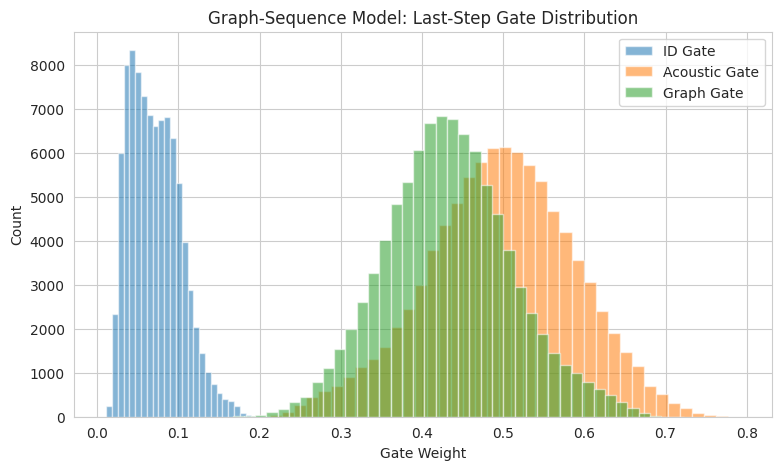

/tmp/ipykernel_556/3921464671.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_mean = item_gate_df.groupby("pop_bucket")[["ID Gate", "Acoustic Gate", "Graph Gate"]].mean()


,ID Gate,Acoustic Gate,Graph Gate
pop_bucket,,,
Q1 Tail,0.014514,0.381598,0.603888
Q2,0.013748,0.383775,0.602477
Q3,0.013509,0.388956,0.597535
Q4 Head,0.014890,0.410664,0.574446


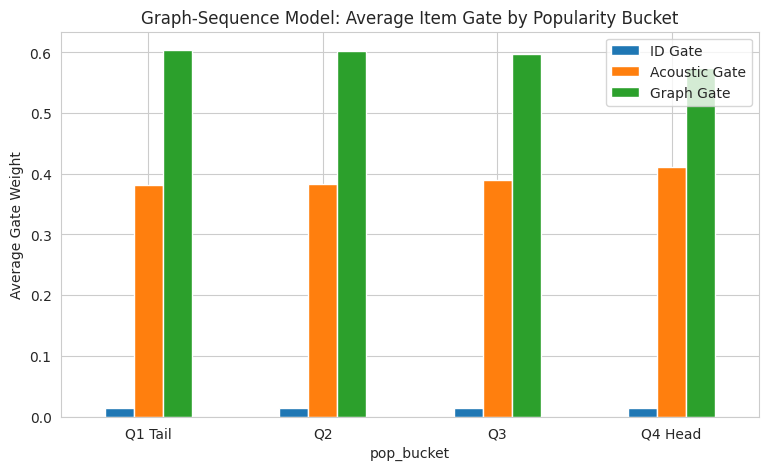

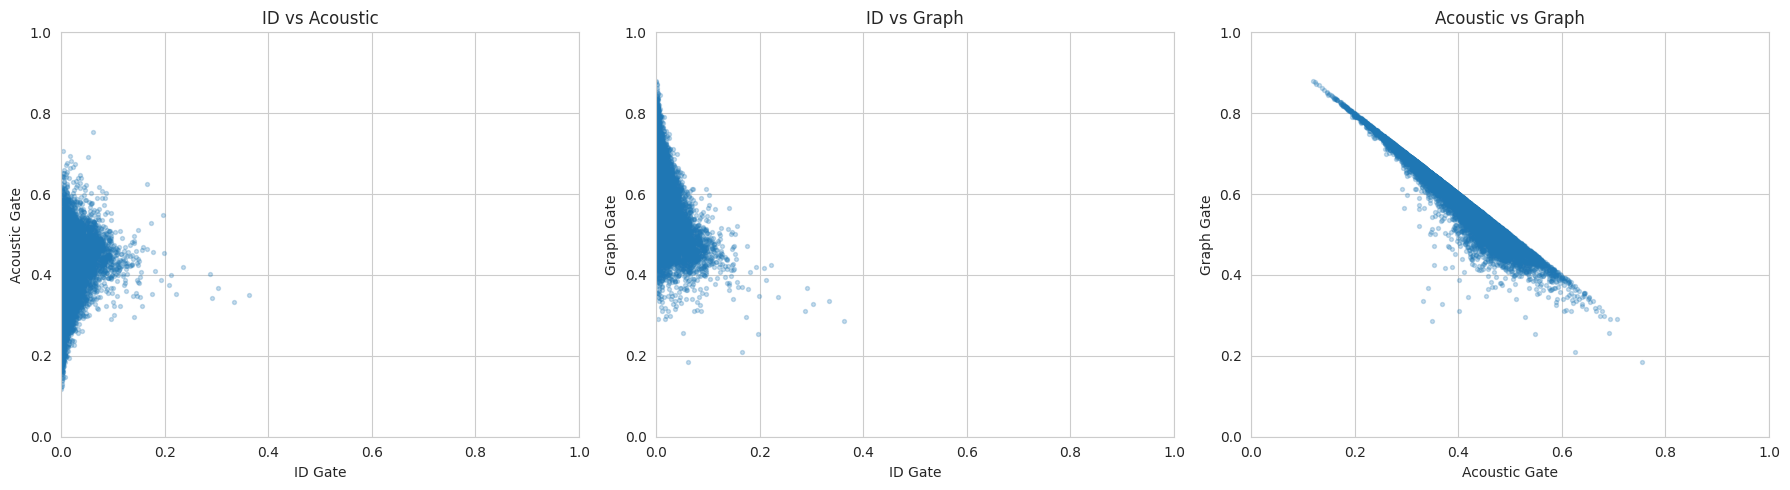

,Sequence Mean,Item Mean
ID Gate,0.071042,0.014165
Acoustic Gate,0.495977,0.391248
Graph Gate,0.432981,0.594587


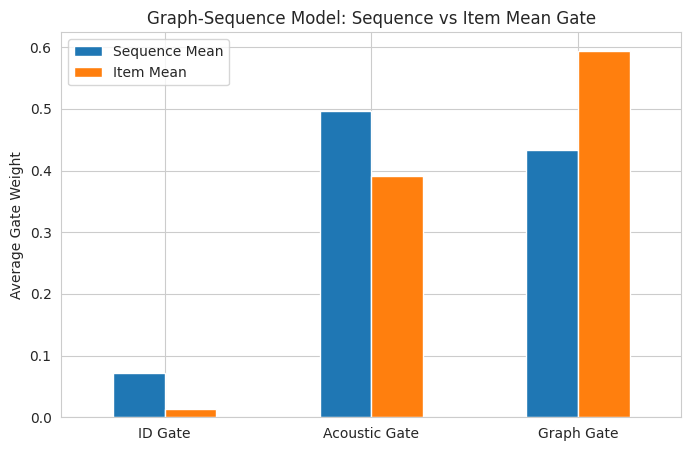

✅ 三流 gate 权重可视化完成！


In [ ]:

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_graph.eval()

print("🎛️ 开始提取三流模型 gate 权重用于可视化...")

# ----------------------------------------------------------
# 1. 序列最后一步 gate 分布
# ----------------------------------------------------------
seq_gate_list = []

with torch.no_grad():
    for x, target in tqdm(test_loader, desc="提取 graph-seq gate"):
        x = x.to(device)
        last_gate = model_graph.get_last_step_gate(x)   # [B, 3]
        seq_gate_list.append(last_gate.cpu())

seq_gates = torch.cat(seq_gate_list, dim=0).numpy()
seq_gate_df = pd.DataFrame({
    "ID Gate": seq_gates[:, 0],
    "Acoustic Gate": seq_gates[:, 1],
    "Graph Gate": seq_gates[:, 2],
})

print(seq_gate_df.describe())

plt.figure(figsize=(9, 5))
plt.hist(seq_gate_df["ID Gate"], bins=40, alpha=0.55, label="ID Gate")
plt.hist(seq_gate_df["Acoustic Gate"], bins=40, alpha=0.55, label="Acoustic Gate")
plt.hist(seq_gate_df["Graph Gate"], bins=40, alpha=0.55, label="Graph Gate")
plt.xlabel("Gate Weight")
plt.ylabel("Count")
plt.title("Graph-Sequence Model: Last-Step Gate Distribution")
plt.legend()
plt.show()

# ----------------------------------------------------------
# 2. item 侧 gate：按流行度分桶
# ----------------------------------------------------------
if 'track_counts' not in locals():
    raise RuntimeError("请先运行三流评估单元，确保 track_counts 已经计算。")

valid_item_ids = torch.nonzero(track_counts > 0).squeeze(1)
valid_item_ids = valid_item_ids[valid_item_ids != 0]

max_items_for_gate_vis = 20000
if valid_item_ids.numel() > max_items_for_gate_vis:
    perm = torch.randperm(valid_item_ids.numel(), device=valid_item_ids.device)[:max_items_for_gate_vis]
    sampled_item_ids = valid_item_ids[perm]
else:
    sampled_item_ids = valid_item_ids

with torch.no_grad():
    _, item_gates = model_graph.get_item_representation(sampled_item_ids.to(device), return_gate=True)

item_gate_df = pd.DataFrame({
    "item_id": sampled_item_ids.cpu().numpy(),
    "count": track_counts[sampled_item_ids].cpu().numpy(),
    "ID Gate": item_gates[:, 0].detach().cpu().numpy(),
    "Acoustic Gate": item_gates[:, 1].detach().cpu().numpy(),
    "Graph Gate": item_gates[:, 2].detach().cpu().numpy(),
})

item_gate_df["pop_bucket"] = pd.qcut(
    item_gate_df["count"].rank(method="first"),
    q=4,
    labels=["Q1 Tail", "Q2", "Q3", "Q4 Head"]
)

bucket_mean = item_gate_df.groupby("pop_bucket")[["ID Gate", "Acoustic Gate", "Graph Gate"]].mean()
display(bucket_mean)

bucket_mean.plot(kind="bar", figsize=(9, 5))
plt.title("Graph-Sequence Model: Average Item Gate by Popularity Bucket")
plt.ylabel("Average Gate Weight")
plt.xticks(rotation=0)
plt.show()

# ----------------------------------------------------------
# 3. 两两散点图：看三模态之间的竞争关系
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(item_gate_df["ID Gate"], item_gate_df["Acoustic Gate"], s=8, alpha=0.25)
axes[0].set_xlabel("ID Gate")
axes[0].set_ylabel("Acoustic Gate")
axes[0].set_title("ID vs Acoustic")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

axes[1].scatter(item_gate_df["ID Gate"], item_gate_df["Graph Gate"], s=8, alpha=0.25)
axes[1].set_xlabel("ID Gate")
axes[1].set_ylabel("Graph Gate")
axes[1].set_title("ID vs Graph")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

axes[2].scatter(item_gate_df["Acoustic Gate"], item_gate_df["Graph Gate"], s=8, alpha=0.25)
axes[2].set_xlabel("Acoustic Gate")
axes[2].set_ylabel("Graph Gate")
axes[2].set_title("Acoustic vs Graph")
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 4. 序列侧 vs item 侧平均 gate 对比
# ----------------------------------------------------------
seq_mean = seq_gate_df.mean().rename("Sequence Mean")
item_mean = item_gate_df[["ID Gate", "Acoustic Gate", "Graph Gate"]].mean().rename("Item Mean")
compare_df = pd.concat([seq_mean, item_mean], axis=1)
display(compare_df)

compare_df.plot(kind="bar", figsize=(8, 5))
plt.title("Graph-Sequence Model: Sequence vs Item Mean Gate")
plt.ylabel("Average Gate Weight")
plt.xticks(rotation=0)
plt.show()

print("✅ 三流 gate 权重可视化完成！")


In [ ]:
# 保存模型，上传至hugging face
from huggingface_hub import upload_file
from huggingface_hub import login

login()

upload_file(
    path_or_fileobj="best_model_graph.pth",
    path_in_repo="best_model_graph.pth",
    repo_id="Pcpp/music-transformer",
    repo_type="model"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  best_model_graph.pth        :   0%|          |  556kB / 9.62GB            

CommitInfo(commit_url='https://huggingface.co/Pcpp/music-transformer/commit/e075f15d16b93f601dff8653856d074d2615cedd', commit_message='Upload best_model_graph.pth with huggingface_hub', commit_description='', oid='e075f15d16b93f601dff8653856d074d2615cedd', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Pcpp/music-transformer', endpoint='https://huggingface.co', repo_type='model', repo_id='Pcpp/music-transformer'), pr_revision=None, pr_num=None)

# 综合对比分析

In [ ]:
# 加载模型
from huggingface_hub import snapshot_download
from huggingface_hub import login
login()

snapshot_download(
    repo_id="Pcpp/music-transformer",
    local_dir="music-transformer",
    resume_download=True,
    max_workers=8
)

model_id_only = torch.load("best_model_id_only.pth.pth")
model = torch.load("best_model_shared_gated_pro.pth")

In [ ]:
import torch
import itertools

print("🛠️ 正在修复：重新计算全局热度统计 (track_counts)...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. 展平训练集序列，极速统计频次
flat_items = list(itertools.chain.from_iterable(train_seqs.values()))
flat_items_tensor = torch.tensor(flat_items, dtype=torch.long, device=device)
track_counts = torch.bincount(flat_items_tensor, minlength=num_tracks + 1)

# 排除 padding (0) 的干扰
track_counts[0] = 0

# 2. 重新提取热门候选集
POOL_SIZE = min(50000, num_tracks)
top_popular_tracks = torch.topk(track_counts, POOL_SIZE).indices

print("✅ track_counts 补全成功！")

🛠️ 正在修复：重新计算全局热度统计 (track_counts)...
✅ track_counts 补全成功！


In [ ]:
# ==========================================
# 0. 防护性补全：测试集 (Test Loader) 与全局属性
# ==========================================
# 重新计算热度和掩码 (防止重启丢失)
flat_items = list(itertools.chain.from_iterable(train_seqs.values()))
flat_items_tensor = torch.tensor(flat_items, dtype=torch.long, device=device)
track_counts = torch.bincount(flat_items_tensor, minlength=num_tracks + 1)
track_counts[0] = 0

POOL_SIZE = min(50000, num_tracks)
top_popular_tracks = torch.topk(track_counts, POOL_SIZE).indices

track_probs = (track_counts / track_counts.sum())
track_novelty = -torch.log2(track_probs + 1e-9)

head_indices = torch.topk(track_counts, min(5000, num_tracks)).indices
is_head_item = torch.zeros(num_tracks + 1, dtype=torch.bool, device=device)
is_head_item[head_indices] = True

# 重新定义 Test DataLoader
class TestSequenceDataset(Dataset):
    def __init__(self, test_seqs, max_len=50):
        self.uids = list(test_seqs.keys())
        self.seqs = [test_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        target = seq[-1]
        hist = seq[:-1][-self.max_len:]
        pad_len = self.max_len - len(hist)
        hist = [0] * pad_len + hist
        return torch.tensor(hist, dtype=torch.long), torch.tensor(target, dtype=torch.long)

if 'MAX_SEQ_LEN' not in locals():
    MAX_SEQ_LEN = 50

test_dataset = TestSequenceDataset(test_seqs, max_len=MAX_SEQ_LEN)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

print("🔍 正在进行极其硬核的【流行度去偏】分层评估 (三模型全量对比)...")

# ==========================================
# 1. 划分 Head, Torso, Tail 集合
# ==========================================
# 按照热度降序排列的 Track IDs
sorted_tracks = torch.argsort(track_counts, descending=True).cpu().numpy()

num_total = len(sorted_tracks)
head_threshold = int(0.05 * num_total)
torso_threshold = int(0.20 * num_total)

head_set = set(sorted_tracks[:head_threshold])
torso_set = set(sorted_tracks[head_threshold:torso_threshold])
tail_set = set(sorted_tracks[torso_threshold:])

# ==========================================
# 2. 准备分层统计容器
# ==========================================
# 分别记录各个区间的总样本数和命中数
strata_results = {
    'ID_Only': {'Head': [0,0], 'Torso': [0,0], 'Tail': [0,0]}, # [hit_count, total_count]
    'FDSA': {'Head': [0,0], 'Torso': [0,0], 'Tail': [0,0]},
    'FDSA_Graph': {'Head': [0,0], 'Torso': [0,0], 'Tail': [0,0]}
}

# ==========================================
# 3. 重新加载模型权重 (确保公平)
# ==========================================
# 1. 纯 ID 模型
model_id_only.load_state_dict(torch.load('/content/drive/MyDrive/music/best_model_id_only.pth'))
model_id_only.eval()

# 2. 🌟 双流模型 (假设你之前的模型实例名为 model，权重保存在 best_model_pro.pth)
# 如果名字不同，请自行修改为你保存的真实文件名
model.load_state_dict(torch.load('/content/drive/MyDrive/music/best_model_pro.pth'))
model.eval()

# 3. 三流终极模型
model_graph.load_state_dict(torch.load('/content/drive/MyDrive/music/best_model_graph.pth'))
model_graph.eval()

print("🚀 开始扫描测试集，进行分层命中判定...")

with torch.no_grad():
    for x, target in tqdm(test_loader, desc="分层评测进度"):
        x, target = x.to(device), target.to(device)
        batch_size = x.size(0)
        target_np = target.cpu().numpy()

        # 准备候选集 (1 正 + 999 负)
        pos_tids = target.unsqueeze(1)
        neg_idx = torch.randint(0, POOL_SIZE, (batch_size, 999), device=device)
        neg_candidates = top_popular_tracks[neg_idx]
        candidates_tids = torch.cat([pos_tids, neg_candidates], dim=1)

        # --- A. 评估纯 ID 模型 ---
        h_id = model_id_only(x)[:, -1, :].unsqueeze(1)
        cand_id = model_id_only.get_item_representation(candidates_tids)
        scores_id = (h_id * cand_id).sum(dim=-1)
        _, top100_id = torch.topk(scores_id, k=100, dim=1)
        hits_id = (top100_id == 0).float().sum(dim=1).cpu().numpy()

        # --- B. 🌟 评估 FDSA 双流模型 ---
        h_fdsa = model(x)[:, -1, :].unsqueeze(1)
        cand_fdsa = model.get_item_representation(candidates_tids)
        scores_fdsa = (h_fdsa * cand_fdsa).sum(dim=-1)
        _, top100_fdsa = torch.topk(scores_fdsa, k=100, dim=1)
        hits_fdsa = (top100_fdsa == 0).float().sum(dim=1).cpu().numpy()

        # --- C. 评估三流终极模型 ---
        h_g = model_graph(x)[:, -1, :].unsqueeze(1)
        cand_g = model_graph.get_item_representation(candidates_tids)
        scores_g = (h_g * cand_g).sum(dim=-1)
        _, top100_g = torch.topk(scores_g, k=100, dim=1)
        hits_g = (top100_g == 0).float().sum(dim=1).cpu().numpy()

        # --- D. 分发结果到各个阶层 ---
        for i in range(batch_size):
            t = target_np[i]
            if t in head_set: group = 'Head'
            elif t in torso_set: group = 'Torso'
            else: group = 'Tail'

            # 统计总数
            strata_results['ID_Only'][group][1] += 1
            strata_results['FDSA'][group][1] += 1
            strata_results['FDSA_Graph'][group][1] += 1

            # 统计命中数
            strata_results['ID_Only'][group][0] += hits_id[i]
            strata_results['FDSA'][group][0] += hits_fdsa[i]
            strata_results['FDSA_Graph'][group][0] += hits_g[i]

# ==========================================
# 4. 打印分层报告
# ==========================================
print("\n" + "="*65)
print("🏆 【深度洞察】三大模型流行度分层抗压测试 (Recall@100)")
print("="*65)
groups = ['Head', 'Torso', 'Tail']
for g in groups:
    count = strata_results['ID_Only'][g][1]
    if count == 0: continue
    rec_id = strata_results['ID_Only'][g][0] / count
    rec_fdsa = strata_results['FDSA'][g][0] / count
    rec_g = strata_results['FDSA_Graph'][g][0] / count

    print(f"🎯 【{g} 组】(占测试集总样本: {count} 个)")
    print(f"   - 纯 ID 基线 : {rec_id:.4f}")
    print(f"   - FDSA (双流): {rec_fdsa:.4f}")
    print(f"   - FDSA-Graph : {rec_g:.4f}  <-- 相较纯 ID 提升了 {(rec_g - rec_id)*100:.2f}%")
    print("-" * 65)

🔍 正在进行极其硬核的【流行度去偏】分层评估 (三模型全量对比)...
🚀 开始扫描测试集，进行分层命中判定...


分层评测进度: 100%|██████████| 194/194 [00:07<00:00, 24.39it/s]


🏆 【深度洞察】三大模型流行度分层抗压测试 (Recall@100)
🎯 【Head 组】(占测试集总样本: 95734 个)
   - 纯 ID 基线 : 0.8011
   - FDSA (双流): 0.8220
   - FDSA-Graph : 0.8083  <-- 相较纯 ID 提升了 0.72%
-----------------------------------------------------------------
🎯 【Torso 组】(占测试集总样本: 3128 个)
   - 纯 ID 基线 : 0.4063
   - FDSA (双流): 0.8242
   - FDSA-Graph : 0.7986  <-- 相较纯 ID 提升了 39.23%
-----------------------------------------------------------------
🎯 【Tail 组】(占测试集总样本: 67 个)
   - 纯 ID 基线 : 0.7313
   - FDSA (双流): 0.8209
   - FDSA-Graph : 0.7612  <-- 相较纯 ID 提升了 2.99%
-----------------------------------------------------------------


In [ ]:
import torch
import numpy as np
from tqdm import tqdm

print("🔍 启动【无掩码纯净流】冷启动极限抗压测试 (剥离 Padding 干扰)...")

# 准备真实容器
true_cold_results = {
    'ID_Only': {'Short (<10)': [0,0], 'Medium (10-30)': [0,0]},
    'FDSA': {'Short (<10)': [0,0], 'Medium (10-30)': [0,0]},
    'FDSA_Graph': {'Short (<10)': [0,0], 'Medium (10-30)': [0,0]}
}

model_id_only.eval()
model.eval()
model_graph.eval()

# 提取所有的短序列和中等序列用户进行逐一(Batch=1)精准打击
cold_users_uids = [uid for uid, seq in test_seqs.items() if len(seq) <= 31]

print(f"🚀 共锁定 {len(cold_users_uids)} 名冷启动/中度活跃用户，开始逐一穿透扫描...")

with torch.no_grad():
    for uid in tqdm(cold_users_uids, desc="真实能力探测"):
        seq = test_seqs[uid]
        target = seq[-1]

        # 🌟 核心：绝对不加任何 0 Padding！保持最原始的纯净序列
        hist = seq[:-1]
        seq_len = len(hist)

        if seq_len == 0: continue # 极个别异常数据跳过

        if seq_len < 10: group = 'Short (<10)'
        else: group = 'Medium (10-30)'

        # 转换为 Batch=1 的 Tensor [1, L]
        x_raw = torch.tensor([hist], dtype=torch.long, device=device)
        pos_tids = torch.tensor([[target]], device=device)

        # 负采样
        neg_idx = torch.randint(0, POOL_SIZE, (1, 999), device=device)
        neg_candidates = top_popular_tracks[neg_idx]
        candidates_tids = torch.cat([pos_tids, neg_candidates], dim=1)

        # ==========================================
        # 释放模型的真实战力 (无需处理 NaN)
        # ==========================================
        # A. 纯 ID 模型
        h_id = model_id_only(x_raw)[:, -1, :].unsqueeze(1)
        cand_id = model_id_only.get_item_representation(candidates_tids)
        scores_id = (h_id * cand_id).sum(dim=-1)
        hit_id = (torch.topk(scores_id, k=10, dim=1)[1] == 0).float().sum().item()

        # B. FDSA 双流模型
        h_fdsa = model(x_raw)[:, -1, :].unsqueeze(1)
        cand_fdsa = model.get_item_representation(candidates_tids)
        scores_fdsa = (h_fdsa * cand_fdsa).sum(dim=-1)
        hit_fdsa = (torch.topk(scores_fdsa, k=10, dim=1)[1] == 0).float().sum().item()

        # C. FDSA-Graph 三流终极模型
        h_g = model_graph(x_raw)[:, -1, :].unsqueeze(1)
        cand_g = model_graph.get_item_representation(candidates_tids)
        scores_g = (h_g * cand_g).sum(dim=-1)
        hit_g = (torch.topk(scores_g, k=10, dim=1)[1] == 0).float().sum().item()

        # 录入成绩
        true_cold_results['ID_Only'][group][1] += 1
        true_cold_results['FDSA'][group][1] += 1
        true_cold_results['FDSA_Graph'][group][1] += 1

        true_cold_results['ID_Only'][group][0] += hit_id
        true_cold_results['FDSA'][group][0] += hit_fdsa
        true_cold_results['FDSA_Graph'][group][0] += hit_g

# ==========================================
# 打印浴火重生的战报
# ==========================================
print("\n" + "="*65)
print("🏆 【真实极限】剥离 Padding 后的用户冷启动真实战力 (Recall@10)")
print("="*65)
for g in ['Short (<10)', 'Medium (10-30)']:
    count = true_cold_results['ID_Only'][g][1]
    if count == 0: continue
    rec_id = true_cold_results['ID_Only'][g][0] / count
    rec_fdsa = true_cold_results['FDSA'][g][0] / count
    rec_g = true_cold_results['FDSA_Graph'][g][0] / count

    print(f"🎯 【{g} 组】(真实无损用户数: {count} 人)")
    print(f"   - 纯 ID 基线 : {rec_id:.4f}")
    print(f"   - FDSA (双流): {rec_fdsa:.4f}")
    print(f"   - FDSA-Graph : {rec_g:.4f}")
    print("-" * 65)

🔍 启动【无掩码纯净流】冷启动极限抗压测试 (剥离 Padding 干扰)...
🚀 共锁定 4252 名冷启动/中度活跃用户，开始逐一穿透扫描...


真实能力探测: 100%|██████████| 4252/4252 [00:47<00:00, 89.30it/s]


🏆 【真实极限】剥离 Padding 后的用户冷启动真实战力 (Recall@10)
🎯 【Short (<10) 组】(真实无损用户数: 1094 人)
   - 纯 ID 基线 : 0.3894
   - FDSA (双流): 0.4305
   - FDSA-Graph : 0.4077
-----------------------------------------------------------------
🎯 【Medium (10-30) 组】(真实无损用户数: 3158 人)
   - 纯 ID 基线 : 0.4218
   - FDSA (双流): 0.4484
   - FDSA-Graph : 0.4231
-----------------------------------------------------------------


In [ ]:
import torch

print("📚 正在探查 Hugging Face 数据集结构...")

# 1. 查看数据结构 (打印第一条数据看看长什么样)
print("\n[Album Mapping 样例]:", album_item_mapping[0])
print("[Artist Mapping 样例]:", artist_item_mapping[0])

# 2. 极速构建双重映射字典
print("\n⚙️ 正在构建 O(1) 复杂度的全局哈希映射字典...")

item_to_album = {}
# 假设字段名为 'item_id' 和 'album_id' (如果报错，请根据上面的打印结果修改字段名)
for row in album_item_mapping:
    item_to_album[int(row['item_id'])] = int(row['album_id'])

item_to_artist = {}
# 假设字段名为 'item_id' 和 'artist_id'
for row in artist_item_mapping:
    item_to_artist[int(row['item_id'])] = int(row['artist_id'])

print(f"✅ 构建完成！共收录了 {len(item_to_album)} 条专辑映射，{len(item_to_artist)} 条艺人映射。")

📚 正在探查 Hugging Face 数据集结构...

[Album Mapping 样例]: {'album_id': 1, 'item_id': 1491131}
[Artist Mapping 样例]: {'artist_id': 1, 'item_id': 953587}

⚙️ 正在构建 O(1) 复杂度的全局哈希映射字典...
✅ 构建完成！共收录了 8653783 条专辑映射，9270506 条艺人映射。


In [ ]:
import random

print("🔍 正在启动【双重图谱语义】微观案例解析 (Case Study)...")

# 升级版信息获取函数
def get_track_info(tid):
    tid_int = int(tid)
    artist_id = item_to_artist.get(tid_int, "未知艺人")
    album_id = item_to_album.get(tid_int, "未知专辑")
    return f"[Track_{tid_int:>7}] (Artist: {artist_id:>6} | Album: {album_id:>7})"

# 寻找具有代表性的中等活跃目标用户 (10~20首)
candidate_uids = [uid for uid, seq in test_seqs.items() if 10 <= len(seq) <= 20]
target_uid = random.choice(candidate_uids)

seq = test_seqs[target_uid]
target_item = seq[-1]
hist_items = seq[:-1]

# 获取 Ground Truth 的高阶图谱信息
target_artist = item_to_artist.get(int(target_item), "未知艺人")
target_album = item_to_album.get(int(target_item), "未知专辑")

print("\n" + "="*85)
print(f"👤 【测试用户 UID: {target_uid}】的结构化听歌脉络")
print("="*85)
print("🎵 [用户的历史听歌序列 (Input Context)]:")
for i, tid in enumerate(hist_items):
    print(f"   {i+1:>2}. {get_track_info(tid)}")
print("-" * 85)
print(f"🎯 [用户接下来真实点击的歌曲 (Ground Truth)]:")
print(f"   👉 {get_track_info(target_item)}")
print("="*85)

# 准备该用户的输入 Tensor
x_raw = torch.tensor([hist_items], dtype=torch.long, device=device)
all_items = torch.arange(1, num_tracks + 1, device=device)

with torch.no_grad():
    print("\n🧠 各大模型的 Top-5 推荐大脑在想什么？")

    # --- A. 纯 ID 模型 ---
    h_id = model_id_only(x_raw)[:, -1, :]
    cand_id = model_id_only.get_item_representation(all_items)
    scores_id = (h_id * cand_id).sum(dim=-1)
    top5_id = torch.topk(scores_id, k=5).indices + 1

    print("\n 1. ID-Only Baseline (纯 ID 协同过滤):")
    for i, tid in enumerate(top5_id.cpu().numpy()):
        match = "🎯 命中 Track!" if tid == target_item else ""
        art_match = "✨ 命中 Artist!" if item_to_artist.get(int(tid)) == target_artist and tid != target_item else ""
        alb_match = "💿 命中 Album!" if item_to_album.get(int(tid)) == target_album and tid != target_item else ""
        print(f"   Top-{i+1}: {get_track_info(tid)} {match}{alb_match}{art_match}")

    # --- B. FDSA 双流模型 ---
    h_fdsa = model(x_raw)[:, -1, :]
    cand_fdsa = model.get_item_representation(all_items)
    scores_fdsa = (h_fdsa * cand_fdsa).sum(dim=-1)
    top5_fdsa = torch.topk(scores_fdsa, k=5).indices + 1

    print("\n 2. FDSA Dual-stream (融合 128维声学特征):")
    for i, tid in enumerate(top5_fdsa.cpu().numpy()):
        match = "🎯 命中 Track!" if tid == target_item else ""
        art_match = "✨ 命中 Artist!" if item_to_artist.get(int(tid)) == target_artist and tid != target_item else ""
        alb_match = "💿 命中 Album!" if item_to_album.get(int(tid)) == target_album and tid != target_item else ""
        print(f"   Top-{i+1}: {get_track_info(tid)} {match}{alb_match}{art_match}")

    # --- C. FDSA-Graph 三流终极模型 ---
    h_g = model_graph(x_raw)[:, -1, :]
    cand_g = model_graph.get_item_representation(all_items)
    scores_g = (h_g * cand_g).sum(dim=-1)
    top5_g = torch.topk(scores_g, k=5).indices + 1

    print("\n 3. FDSA-Graph Tri-stream (图谱协同 + 声学多模态):")
    for i, tid in enumerate(top5_g.cpu().numpy()):
        match = "🎯 命中 Track!" if tid == target_item else ""
        art_match = "✨ 命中 Artist!" if item_to_artist.get(int(tid)) == target_artist and tid != target_item else ""
        alb_match = "💿 命中 Album!" if item_to_album.get(int(tid)) == target_album and tid != target_item else ""
        print(f"   Top-{i+1}: {get_track_info(tid)} {match}{alb_match}{art_match}")
print("\n" + "="*85)

🔍 正在启动【双重图谱语义】微观案例解析 (Case Study)...

👤 【测试用户 UID: 819940】的结构化听歌脉络
🎵 [用户的历史听歌序列 (Input Context)]:
    1. [Track_5937920] (Artist: 600159 | Album: 1938673)
    2. [Track_3655998] (Artist: 600159 | Album: 2292308)
    3. [Track_2701068] (Artist: 600159 | Album: 1938673)
    4. [Track_3646870] (Artist: 600159 | Album: 1938673)
    5. [Track_2751657] (Artist: 600159 | Album: 1938673)
    6. [Track_9026138] (Artist: 600159 | Album: 2292308)
    7. [Track_8974272] (Artist: 600159 | Album: 3029221)
    8. [Track_2796623] (Artist: 600159 | Album: 1938673)
    9. [Track_6907822] (Artist: 600159 | Album: 1938673)
   10. [Track_4414462] (Artist: 600159 | Album: 1938673)
-------------------------------------------------------------------------------------
🎯 [用户接下来真实点击的歌曲 (Ground Truth)]:
   👉 [Track_6907822] (Artist: 600159 | Album: 1938673)

🧠 各大模型的 Top-5 推荐大脑在想什么？

 1. ID-Only Baseline (纯 ID 协同过滤):
   Top-1: [Track_3646870] (Artist: 600159 | Album: 1938673) 💿 命中 Album!✨ 命中 Artist!
   Top-2: [Tra

In [ ]:
import re
import matplotlib.pyplot as plt

# 1. 你的完整训练日志（直接粘贴在这里）
log_text = """
   Batch 100/387 | Loss: 9.5056
   Batch 200/387 | Loss: 9.4727
   Batch 300/387 | Loss: 9.4297
✅ Epoch 1 | Avg Loss: 9.4572 | Val AUC: 0.5522 | Time: 32.7s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 9.3722
   Batch 200/387 | Loss: 9.3917
   Batch 300/387 | Loss: 9.3425
✅ Epoch 2 | Avg Loss: 9.3807 | Val AUC: 0.5835 | Time: 31.7s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 9.3027
   Batch 200/387 | Loss: 9.2767
   Batch 300/387 | Loss: 9.2515
✅ Epoch 3 | Avg Loss: 9.2737 | Val AUC: 0.6297 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 9.1710
   Batch 200/387 | Loss: 9.1524
   Batch 300/387 | Loss: 9.1801
✅ Epoch 4 | Avg Loss: 9.1568 | Val AUC: 0.6737 | Time: 39.9s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 9.0453
   Batch 200/387 | Loss: 9.0174
   Batch 300/387 | Loss: 9.0333
✅ Epoch 5 | Avg Loss: 9.0395 | Val AUC: 0.7140 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.9352
   Batch 200/387 | Loss: 8.9567
   Batch 300/387 | Loss: 8.9130
✅ Epoch 6 | Avg Loss: 8.9273 | Val AUC: 0.7434 | Time: 31.3s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.8374
   Batch 200/387 | Loss: 8.8211
   Batch 300/387 | Loss: 8.8280
✅ Epoch 7 | Avg Loss: 8.8250 | Val AUC: 0.7696 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.7774
   Batch 200/387 | Loss: 8.7261
   Batch 300/387 | Loss: 8.7470
✅ Epoch 8 | Avg Loss: 8.7324 | Val AUC: 0.7895 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.7331
   Batch 200/387 | Loss: 8.6374
   Batch 300/387 | Loss: 8.6689
✅ Epoch 9 | Avg Loss: 8.6480 | Val AUC: 0.8064 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.5852
   Batch 200/387 | Loss: 8.5273
   Batch 300/387 | Loss: 8.5537
✅ Epoch 10 | Avg Loss: 8.5705 | Val AUC: 0.8213 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.5759
   Batch 200/387 | Loss: 8.5179
   Batch 300/387 | Loss: 8.4542
✅ Epoch 11 | Avg Loss: 8.4990 | Val AUC: 0.8327 | Time: 40.3s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.4685
   Batch 200/387 | Loss: 8.4390
   Batch 300/387 | Loss: 8.4261
✅ Epoch 12 | Avg Loss: 8.4326 | Val AUC: 0.8419 | Time: 31.6s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.3717
   Batch 200/387 | Loss: 8.3889
   Batch 300/387 | Loss: 8.3746
✅ Epoch 13 | Avg Loss: 8.3712 | Val AUC: 0.8505 | Time: 31.6s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.2945
   Batch 200/387 | Loss: 8.3544
   Batch 300/387 | Loss: 8.2869
✅ Epoch 14 | Avg Loss: 8.3145 | Val AUC: 0.8581 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.2208
   Batch 200/387 | Loss: 8.2217
   Batch 300/387 | Loss: 8.1984
✅ Epoch 15 | Avg Loss: 8.2622 | Val AUC: 0.8649 | Time: 40.0s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.2262
   Batch 200/387 | Loss: 8.2296
   Batch 300/387 | Loss: 8.1751
✅ Epoch 16 | Avg Loss: 8.2124 | Val AUC: 0.8700 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.1985
   Batch 200/387 | Loss: 8.1862
   Batch 300/387 | Loss: 8.1445
✅ Epoch 17 | Avg Loss: 8.1666 | Val AUC: 0.8755 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.0907
   Batch 200/387 | Loss: 8.1444
   Batch 300/387 | Loss: 8.0876
✅ Epoch 18 | Avg Loss: 8.1250 | Val AUC: 0.8791 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.0752
   Batch 200/387 | Loss: 8.1249
   Batch 300/387 | Loss: 8.1022
✅ Epoch 19 | Avg Loss: 8.0851 | Val AUC: 0.8823 | Time: 31.6s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.0990
   Batch 200/387 | Loss: 8.0256
   Batch 300/387 | Loss: 8.0706
✅ Epoch 20 | Avg Loss: 8.0477 | Val AUC: 0.8847 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9938
   Batch 200/387 | Loss: 7.9438
   Batch 300/387 | Loss: 8.0496
✅ Epoch 21 | Avg Loss: 8.0128 | Val AUC: 0.8882 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.0058
   Batch 200/387 | Loss: 8.0453
   Batch 300/387 | Loss: 7.9146
✅ Epoch 22 | Avg Loss: 7.9805 | Val AUC: 0.8910 | Time: 40.0s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9636
   Batch 200/387 | Loss: 7.9129
   Batch 300/387 | Loss: 7.9369
✅ Epoch 23 | Avg Loss: 7.9500 | Val AUC: 0.8923 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9371
   Batch 200/387 | Loss: 7.9549
   Batch 300/387 | Loss: 7.8873
✅ Epoch 24 | Avg Loss: 7.9213 | Val AUC: 0.8959 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9050
   Batch 200/387 | Loss: 7.8972
   Batch 300/387 | Loss: 7.9063
✅ Epoch 25 | Avg Loss: 7.8935 | Val AUC: 0.8971 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9006
   Batch 200/387 | Loss: 7.8400
   Batch 300/387 | Loss: 7.8320
✅ Epoch 26 | Avg Loss: 7.8676 | Val AUC: 0.8986 | Time: 40.1s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.8834
   Batch 200/387 | Loss: 7.8835
   Batch 300/387 | Loss: 7.9187
✅ Epoch 27 | Avg Loss: 7.8432 | Val AUC: 0.9000 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.8408
   Batch 200/387 | Loss: 7.7530
   Batch 300/387 | Loss: 7.8249
✅ Epoch 28 | Avg Loss: 7.8192 | Val AUC: 0.9020 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7636
   Batch 200/387 | Loss: 7.8249
   Batch 300/387 | Loss: 7.7778
✅ Epoch 29 | Avg Loss: 7.7973 | Val AUC: 0.9031 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7397
   Batch 200/387 | Loss: 7.7439
   Batch 300/387 | Loss: 7.8045
✅ Epoch 30 | Avg Loss: 7.7765 | Val AUC: 0.9042 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7550
   Batch 200/387 | Loss: 7.8044
   Batch 300/387 | Loss: 7.7465
✅ Epoch 31 | Avg Loss: 7.7563 | Val AUC: 0.9050 | Time: 31.4s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7712
   Batch 200/387 | Loss: 7.7611
   Batch 300/387 | Loss: 7.7971
✅ Epoch 32 | Avg Loss: 7.7370 | Val AUC: 0.9058 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7593
   Batch 200/387 | Loss: 7.7065
   Batch 300/387 | Loss: 7.7568
✅ Epoch 33 | Avg Loss: 7.7185 | Val AUC: 0.9077 | Time: 40.0s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6877
   Batch 200/387 | Loss: 7.6975
   Batch 300/387 | Loss: 7.6443
✅ Epoch 34 | Avg Loss: 7.7014 | Val AUC: 0.9076 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.7363
   Batch 200/387 | Loss: 7.6811
   Batch 300/387 | Loss: 7.6667
✅ Epoch 35 | Avg Loss: 7.6845 | Val AUC: 0.9094 | Time: 31.3s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6750
   Batch 200/387 | Loss: 7.6235
   Batch 300/387 | Loss: 7.6851
✅ Epoch 36 | Avg Loss: 7.6686 | Val AUC: 0.9096 | Time: 31.6s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6654
   Batch 200/387 | Loss: 7.6611
   Batch 300/387 | Loss: 7.6625
✅ Epoch 37 | Avg Loss: 7.6534 | Val AUC: 0.9098 | Time: 40.1s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6026
   Batch 200/387 | Loss: 7.7245
   Batch 300/387 | Loss: 7.6191
✅ Epoch 38 | Avg Loss: 7.6384 | Val AUC: 0.9111 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6808
   Batch 200/387 | Loss: 7.5949
   Batch 300/387 | Loss: 7.6385
✅ Epoch 39 | Avg Loss: 7.6247 | Val AUC: 0.9113 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.5797
   Batch 200/387 | Loss: 7.6294
   Batch 300/387 | Loss: 7.5131
✅ Epoch 40 | Avg Loss: 7.6111 | Val AUC: 0.9117 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.5984
   Batch 200/387 | Loss: 7.6552
   Batch 300/387 | Loss: 7.6342
✅ Epoch 41 | Avg Loss: 7.5977 | Val AUC: 0.9129 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6170
   Batch 200/387 | Loss: 7.6100
   Batch 300/387 | Loss: 7.5410
✅ Epoch 42 | Avg Loss: 7.5851 | Val AUC: 0.9131 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.5949
   Batch 200/387 | Loss: 7.6186
   Batch 300/387 | Loss: 7.6066
✅ Epoch 43 | Avg Loss: 7.5733 | Val AUC: 0.9128 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5347
   Batch 200/387 | Loss: 7.5456
   Batch 300/387 | Loss: 7.5887
✅ Epoch 44 | Avg Loss: 7.5619 | Val AUC: 0.9145 | Time: 39.9s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.5988
   Batch 200/387 | Loss: 7.5479
   Batch 300/387 | Loss: 7.5009
✅ Epoch 45 | Avg Loss: 7.5507 | Val AUC: 0.9141 | Time: 31.6s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5911
   Batch 200/387 | Loss: 7.5288
   Batch 300/387 | Loss: 7.5230
✅ Epoch 46 | Avg Loss: 7.5394 | Val AUC: 0.9143 | Time: 31.8s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5080
   Batch 200/387 | Loss: 7.5009
   Batch 300/387 | Loss: 7.5594
✅ Epoch 47 | Avg Loss: 7.5298 | Val AUC: 0.9147 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.5860
   Batch 200/387 | Loss: 7.4714
   Batch 300/387 | Loss: 7.4582
✅ Epoch 48 | Avg Loss: 7.5197 | Val AUC: 0.9142 | Time: 40.2s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5723
   Batch 200/387 | Loss: 7.5268
   Batch 300/387 | Loss: 7.5291
✅ Epoch 49 | Avg Loss: 7.5099 | Val AUC: 0.9149 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4377
   Batch 200/387 | Loss: 7.4706
   Batch 300/387 | Loss: 7.4836
✅ Epoch 50 | Avg Loss: 7.5006 | Val AUC: 0.9154 | Time: 31.9s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4578
   Batch 200/387 | Loss: 7.5639
   Batch 300/387 | Loss: 7.4852
✅ Epoch 51 | Avg Loss: 7.4919 | Val AUC: 0.9161 | Time: 31.9s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.5991
   Batch 200/387 | Loss: 7.4642
   Batch 300/387 | Loss: 7.4956
✅ Epoch 52 | Avg Loss: 7.4832 | Val AUC: 0.9152 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5083
   Batch 200/387 | Loss: 7.4850
   Batch 300/387 | Loss: 7.4562
✅ Epoch 53 | Avg Loss: 7.4741 | Val AUC: 0.9160 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4853
   Batch 200/387 | Loss: 7.4523
   Batch 300/387 | Loss: 7.5086
✅ Epoch 54 | Avg Loss: 7.4659 | Val AUC: 0.9165 | Time: 40.0s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4825
   Batch 200/387 | Loss: 7.4698
   Batch 300/387 | Loss: 7.5216
✅ Epoch 55 | Avg Loss: 7.4592 | Val AUC: 0.9166 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4974
   Batch 200/387 | Loss: 7.4722
   Batch 300/387 | Loss: 7.3691
✅ Epoch 56 | Avg Loss: 7.4513 | Val AUC: 0.9166 | Time: 31.6s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4794
   Batch 200/387 | Loss: 7.4505
   Batch 300/387 | Loss: 7.4240
✅ Epoch 57 | Avg Loss: 7.4441 | Val AUC: 0.9173 | Time: 31.4s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4846
   Batch 200/387 | Loss: 7.4432
   Batch 300/387 | Loss: 7.4960
✅ Epoch 58 | Avg Loss: 7.4370 | Val AUC: 0.9171 | Time: 31.4s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4774
   Batch 200/387 | Loss: 7.3915
   Batch 300/387 | Loss: 7.4197
✅ Epoch 59 | Avg Loss: 7.4298 | Val AUC: 0.9178 | Time: 39.9s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4143
   Batch 200/387 | Loss: 7.4245
   Batch 300/387 | Loss: 7.4117
✅ Epoch 60 | Avg Loss: 7.4234 | Val AUC: 0.9175 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4335
   Batch 200/387 | Loss: 7.4286
   Batch 300/387 | Loss: 7.4322
✅ Epoch 61 | Avg Loss: 7.4169 | Val AUC: 0.9182 | Time: 31.4s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.3931
   Batch 200/387 | Loss: 7.4029
   Batch 300/387 | Loss: 7.4445
✅ Epoch 62 | Avg Loss: 7.4101 | Val AUC: 0.9191 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4515
   Batch 200/387 | Loss: 7.3537
   Batch 300/387 | Loss: 7.4463
✅ Epoch 63 | Avg Loss: 7.4041 | Val AUC: 0.9175 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4241
   Batch 200/387 | Loss: 7.3957
   Batch 300/387 | Loss: 7.3763
✅ Epoch 64 | Avg Loss: 7.3983 | Val AUC: 0.9186 | Time: 31.4s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3951
   Batch 200/387 | Loss: 7.3455
   Batch 300/387 | Loss: 7.3927
✅ Epoch 65 | Avg Loss: 7.3926 | Val AUC: 0.9186 | Time: 40.0s
📉 AUC 未提升 | 早停计数: 3/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3926
   Batch 200/387 | Loss: 7.4231
   Batch 300/387 | Loss: 7.4281
✅ Epoch 66 | Avg Loss: 7.3865 | Val AUC: 0.9188 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 4/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3388
   Batch 200/387 | Loss: 7.3978
   Batch 300/387 | Loss: 7.3811
✅ Epoch 67 | Avg Loss: 7.3815 | Val AUC: 0.9191 | Time: 31.7s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4206
   Batch 200/387 | Loss: 7.3288
   Batch 300/387 | Loss: 7.3668
✅ Epoch 68 | Avg Loss: 7.3765 | Val AUC: 0.9193 | Time: 31.8s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.3748
   Batch 200/387 | Loss: 7.3877
   Batch 300/387 | Loss: 7.3798
✅ Epoch 69 | Avg Loss: 7.3714 | Val AUC: 0.9185 | Time: 31.7s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3483
   Batch 200/387 | Loss: 7.4535
   Batch 300/387 | Loss: 7.3428
✅ Epoch 70 | Avg Loss: 7.3669 | Val AUC: 0.9182 | Time: 40.0s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3454
   Batch 200/387 | Loss: 7.3108
   Batch 300/387 | Loss: 7.3482
✅ Epoch 71 | Avg Loss: 7.3620 | Val AUC: 0.9193 | Time: 31.4s
📉 AUC 未提升 | 早停计数: 3/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3753
   Batch 200/387 | Loss: 7.3672
   Batch 300/387 | Loss: 7.3931
✅ Epoch 72 | Avg Loss: 7.3568 | Val AUC: 0.9193 | Time: 31.4s
📉 AUC 未提升 | 早停计数: 4/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3774
   Batch 200/387 | Loss: 7.3307
   Batch 300/387 | Loss: 7.3542
✅ Epoch 73 | Avg Loss: 7.3522 | Val AUC: 0.9190 | Time: 31.4s
📉 AUC 未提升 | 早停计数: 5/5
🛑 停止训练

"""



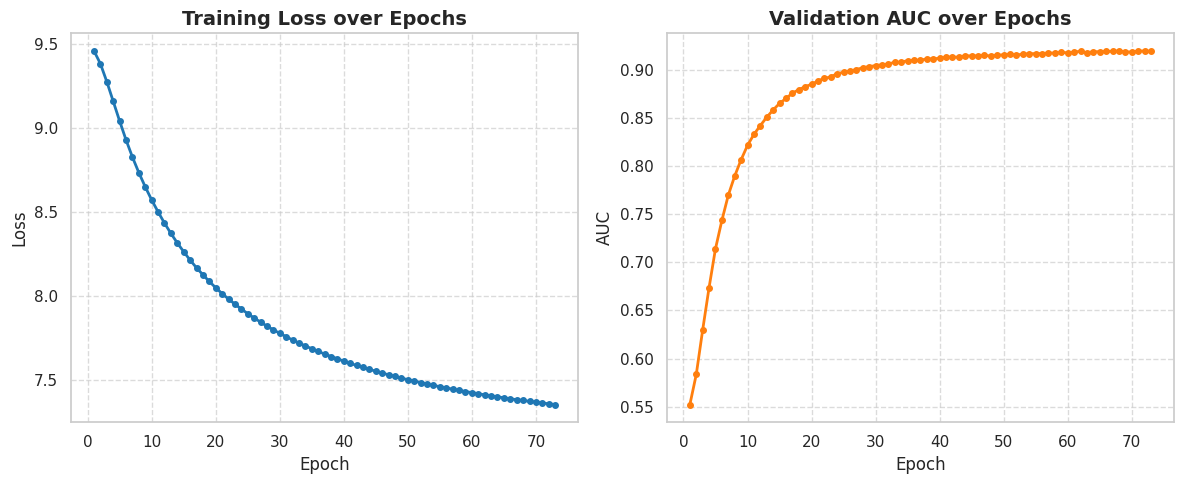

✅ 高清训练曲线图已生成并保存为 'model_id_training_curves.png'！


In [ ]:
# 2. 初始化数据列表
epochs = []
losses = []
aucs = []

# 3. 使用正则表达式提取关键数据
# 匹配类似 "Epoch 1 | Avg Loss: 9.4572 | Val AUC: 0.5522" 的行
pattern = r"Epoch (\d+) \| Avg Loss: ([\d.]+) \| Val AUC: ([\d.]+)"

for match in re.finditer(pattern, log_text):
    epochs.append(int(match.group(1)))       # 提取 Epoch 数字
    losses.append(float(match.group(2)))     # 提取 Loss 数字
    aucs.append(float(match.group(3)))       # 提取 AUC 数字

# 4. 开启学术级绘图 (使用 seaborn 风格会让图更好看，可选)
import seaborn as sns
sns.set_theme(style="whitegrid") # 设置带网格的白底风格，非常适合论文

# 创建一个 1 行 2 列的画板
plt.figure(figsize=(12, 5))

# --- 绘制第一张图：Training Loss ---
plt.subplot(1, 2, 1)
# 'o-' 表示带圆点的实线，color 设置颜色，linewidth 设置线宽
plt.plot(epochs, losses, 'o-', color='#1f77b4', markersize=4, linewidth=2)
plt.title('Training Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# --- 绘制第二张图：Validation AUC ---
plt.subplot(1, 2, 2)
plt.plot(epochs, aucs, 'o-', color='#ff7f0e', markersize=4, linewidth=2)
plt.title('Validation AUC over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 自动调整子图间距
plt.tight_layout()

# 5. 保存高清图片到本地 (dpi=300 是顶会论文的标准清晰度)
plt.savefig('model_id_training_curves.png', dpi=300, bbox_inches='tight')

# 显示图片
plt.show()

print("✅ 高清训练曲线图已生成并保存为 'model_id_training_curves.png'！")

In [ ]:
import re
import matplotlib.pyplot as plt

# 1. 你的完整训练日志（直接粘贴在这里）
log_text = """

🔥 启动增强版训练 (L2 Normalization + Optimized Temp)...
   Batch 100/387 | Loss: 8.2475
   Batch 200/387 | Loss: 8.1533
   Batch 300/387 | Loss: 8.1253
✅ Epoch 1 | Avg Loss: 8.2448 | Val AUC: 0.8870 | Time: 68.2s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.0348
   Batch 200/387 | Loss: 7.9627
   Batch 300/387 | Loss: 8.0211
✅ Epoch 2 | Avg Loss: 8.0070 | Val AUC: 0.8957 | Time: 67.1s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9287
   Batch 200/387 | Loss: 7.9596
   Batch 300/387 | Loss: 7.8959
✅ Epoch 3 | Avg Loss: 7.9241 | Val AUC: 0.9036 | Time: 67.2s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.8892
   Batch 200/387 | Loss: 7.8387
   Batch 300/387 | Loss: 7.8091
✅ Epoch 4 | Avg Loss: 7.8572 | Val AUC: 0.9039 | Time: 67.2s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.8148
   Batch 200/387 | Loss: 7.7344
   Batch 300/387 | Loss: 7.7704
✅ Epoch 5 | Avg Loss: 7.7995 | Val AUC: 0.9086 | Time: 67.2s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7894
   Batch 200/387 | Loss: 7.7157
   Batch 300/387 | Loss: 7.8143
✅ Epoch 6 | Avg Loss: 7.7517 | Val AUC: 0.9098 | Time: 75.7s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7323
   Batch 200/387 | Loss: 7.6862
   Batch 300/387 | Loss: 7.6665
✅ Epoch 7 | Avg Loss: 7.7111 | Val AUC: 0.9090 | Time: 67.3s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.6698
   Batch 200/387 | Loss: 7.6957
   Batch 300/387 | Loss: 7.7011
✅ Epoch 8 | Avg Loss: 7.6763 | Val AUC: 0.9106 | Time: 67.2s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6290
   Batch 200/387 | Loss: 7.7314
   Batch 300/387 | Loss: 7.6473
✅ Epoch 9 | Avg Loss: 7.6464 | Val AUC: 0.9120 | Time: 67.3s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6665
   Batch 200/387 | Loss: 7.6338
   Batch 300/387 | Loss: 7.5800
✅ Epoch 10 | Avg Loss: 7.6204 | Val AUC: 0.9119 | Time: 75.6s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5935
   Batch 200/387 | Loss: 7.6098
   Batch 300/387 | Loss: 7.5712
✅ Epoch 11 | Avg Loss: 7.5976 | Val AUC: 0.9157 | Time: 67.1s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6006
   Batch 200/387 | Loss: 7.5086
   Batch 300/387 | Loss: 7.5729
✅ Epoch 12 | Avg Loss: 7.5765 | Val AUC: 0.9133 | Time: 67.3s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5422
   Batch 200/387 | Loss: 7.5284
   Batch 300/387 | Loss: 7.5728
✅ Epoch 13 | Avg Loss: 7.5575 | Val AUC: 0.9154 | Time: 67.2s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5983
   Batch 200/387 | Loss: 7.5604
   Batch 300/387 | Loss: 7.5637
✅ Epoch 14 | Avg Loss: 7.5421 | Val AUC: 0.9127 | Time: 67.2s
📉 AUC 未提升 | 早停计数: 3/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4812
   Batch 200/387 | Loss: 7.4950
   Batch 300/387 | Loss: 7.5624
✅ Epoch 15 | Avg Loss: 7.5269 | Val AUC: 0.9149 | Time: 67.1s
📉 AUC 未提升 | 早停计数: 4/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4616
   Batch 200/387 | Loss: 7.4979
   Batch 300/387 | Loss: 7.5457
✅ Epoch 16 | Avg Loss: 7.5127 | Val AUC: 0.9179 | Time: 67.1s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4894
   Batch 200/387 | Loss: 7.5207
   Batch 300/387 | Loss: 7.6075
✅ Epoch 17 | Avg Loss: 7.5005 | Val AUC: 0.9135 | Time: 75.6s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4151
   Batch 200/387 | Loss: 7.4675
   Batch 300/387 | Loss: 7.4939
✅ Epoch 18 | Avg Loss: 7.4890 | Val AUC: 0.9148 | Time: 67.3s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5108
   Batch 200/387 | Loss: 7.4580
   Batch 300/387 | Loss: 7.5337
✅ Epoch 19 | Avg Loss: 7.4774 | Val AUC: 0.9171 | Time: 67.3s
📉 AUC 未提升 | 早停计数: 3/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3841
   Batch 200/387 | Loss: 7.4659
   Batch 300/387 | Loss: 7.4795
✅ Epoch 20 | Avg Loss: 7.4667 | Val AUC: 0.9160 | Time: 67.3s
📉 AUC 未提升 | 早停计数: 4/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4422
   Batch 200/387 | Loss: 7.4051
   Batch 300/387 | Loss: 7.4678
✅ Epoch 21 | Avg Loss: 7.4574 | Val AUC: 0.9142 | Time: 75.7s
📉 AUC 未提升 | 早停计数: 5/5
🛑 停止训练

"""



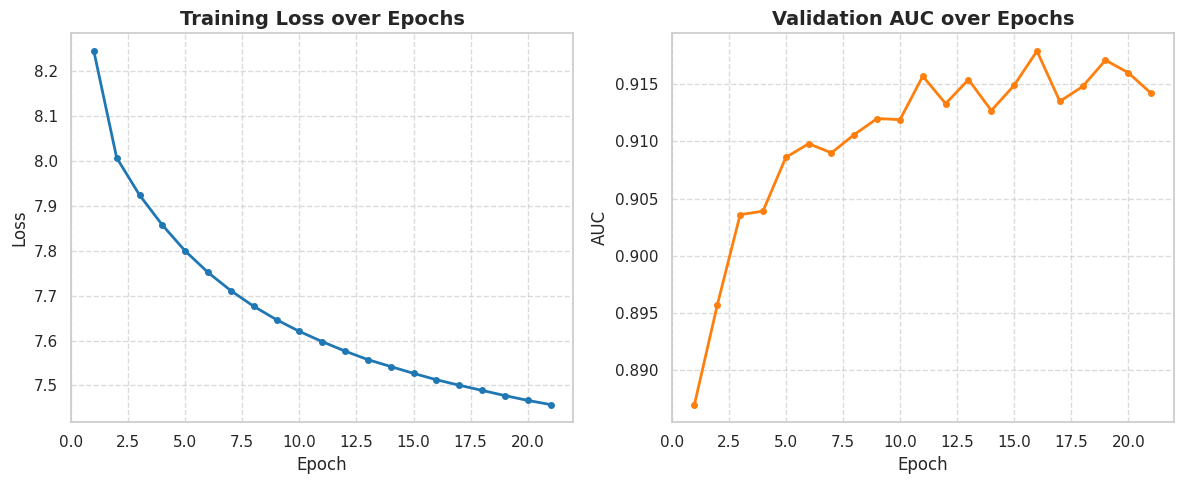

✅ 高清训练曲线图已生成并保存为 'model_pro_training_curves.png'！


In [ ]:
# 2. 初始化数据列表
epochs = []
losses = []
aucs = []

# 3. 使用正则表达式提取关键数据
# 匹配类似 "Epoch 1 | Avg Loss: 9.4572 | Val AUC: 0.5522" 的行
pattern = r"Epoch (\d+) \| Avg Loss: ([\d.]+) \| Val AUC: ([\d.]+)"

for match in re.finditer(pattern, log_text):
    epochs.append(int(match.group(1)))       # 提取 Epoch 数字
    losses.append(float(match.group(2)))     # 提取 Loss 数字
    aucs.append(float(match.group(3)))       # 提取 AUC 数字

# 4. 开启学术级绘图 (使用 seaborn 风格会让图更好看，可选)
import seaborn as sns
sns.set_theme(style="whitegrid") # 设置带网格的白底风格，非常适合论文

# 创建一个 1 行 2 列的画板
plt.figure(figsize=(12, 5))

# --- 绘制第一张图：Training Loss ---
plt.subplot(1, 2, 1)
# 'o-' 表示带圆点的实线，color 设置颜色，linewidth 设置线宽
plt.plot(epochs, losses, 'o-', color='#1f77b4', markersize=4, linewidth=2)
plt.title('Training Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# --- 绘制第二张图：Validation AUC ---
plt.subplot(1, 2, 2)
plt.plot(epochs, aucs, 'o-', color='#ff7f0e', markersize=4, linewidth=2)
plt.title('Validation AUC over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 自动调整子图间距
plt.tight_layout()

# 5. 保存高清图片到本地 (dpi=300 是顶会论文的标准清晰度)
plt.savefig('model_pro_training_curves.png', dpi=300, bbox_inches='tight')

# 显示图片
plt.show()

print("✅ 高清训练曲线图已生成并保存为 'model_pro_training_curves.png'！")

In [ ]:
import re
import matplotlib.pyplot as plt

# 1. 你的完整训练日志（直接粘贴在这里）
log_text = """


🔥 启动终极杀手锏训练 (图谱 + 声学 + ID 三流融合)...
   Batch 100/387 | Loss: 8.2559
   Batch 200/387 | Loss: 8.1295
   Batch 300/387 | Loss: 8.0990
✅ Epoch 1 | Avg Loss: 8.2258 | Val AUC: 0.9003 | Time: 87.1s
🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9096
   Batch 200/387 | Loss: 7.8831
   Batch 300/387 | Loss: 7.8292
✅ Epoch 2 | Avg Loss: 7.9133 | Val AUC: 0.9085 | Time: 86.2s
🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.8099
   Batch 200/387 | Loss: 7.7810
   Batch 300/387 | Loss: 7.7566
✅ Epoch 3 | Avg Loss: 7.7895 | Val AUC: 0.9129 | Time: 86.2s
🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7111
   Batch 200/387 | Loss: 7.7376
   Batch 300/387 | Loss: 7.7212
✅ Epoch 4 | Avg Loss: 7.7121 | Val AUC: 0.9181 | Time: 94.7s
🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6822
   Batch 200/387 | Loss: 7.5834
   Batch 300/387 | Loss: 7.6863
✅ Epoch 5 | Avg Loss: 7.6555 | Val AUC: 0.9143 | Time: 86.2s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.6207
   Batch 200/387 | Loss: 7.5430
   Batch 300/387 | Loss: 7.6108
✅ Epoch 6 | Avg Loss: 7.6101 | Val AUC: 0.9180 | Time: 86.1s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5502
   Batch 200/387 | Loss: 7.4932
   Batch 300/387 | Loss: 7.6099
✅ Epoch 7 | Avg Loss: 7.5728 | Val AUC: 0.9176 | Time: 86.2s
📉 AUC 未提升 | 早停计数: 3/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5732
   Batch 200/387 | Loss: 7.5577
   Batch 300/387 | Loss: 7.5847
✅ Epoch 8 | Avg Loss: 7.5401 | Val AUC: 0.9177 | Time: 86.2s
📉 AUC 未提升 | 早停计数: 4/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5776
   Batch 200/387 | Loss: 7.5275
   Batch 300/387 | Loss: 7.4965
✅ Epoch 9 | Avg Loss: 7.5127 | Val AUC: 0.9173 | Time: 86.2s
📉 AUC 未提升 | 早停计数: 5/5
🛑 训练圆满结束 (触发早停)


"""


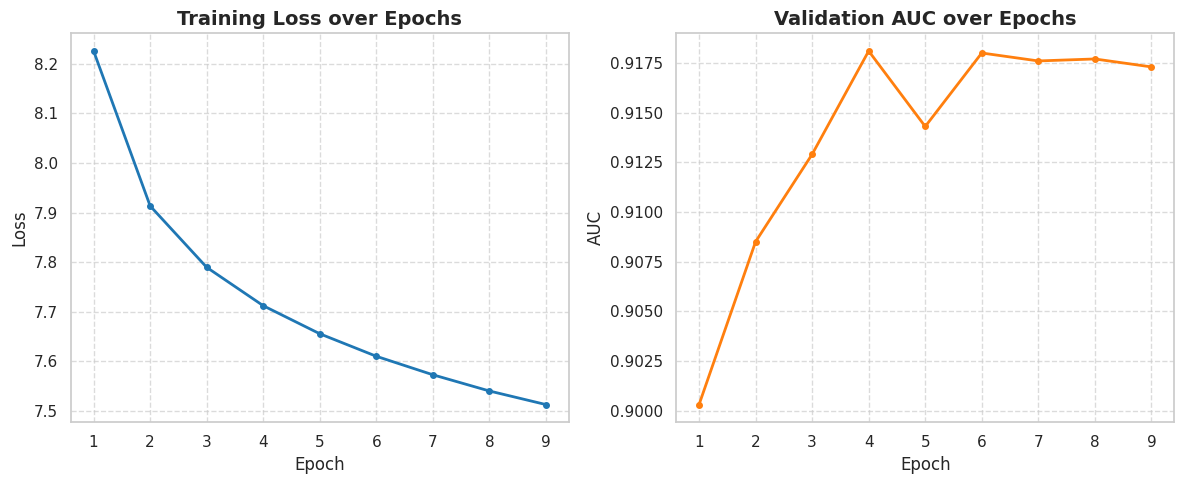

✅ 高清训练曲线图已生成并保存为 'model_graph_training_curves.png'！


In [ ]:
# 2. 初始化数据列表
epochs = []
losses = []
aucs = []

# 3. 使用正则表达式提取关键数据
# 匹配类似 "Epoch 1 | Avg Loss: 9.4572 | Val AUC: 0.5522" 的行
pattern = r"Epoch (\d+) \| Avg Loss: ([\d.]+) \| Val AUC: ([\d.]+)"

for match in re.finditer(pattern, log_text):
    epochs.append(int(match.group(1)))       # 提取 Epoch 数字
    losses.append(float(match.group(2)))     # 提取 Loss 数字
    aucs.append(float(match.group(3)))       # 提取 AUC 数字

# 4. 开启学术级绘图 (使用 seaborn 风格会让图更好看，可选)
import seaborn as sns
sns.set_theme(style="whitegrid") # 设置带网格的白底风格，非常适合论文

# 创建一个 1 行 2 列的画板
plt.figure(figsize=(12, 5))

# --- 绘制第一张图：Training Loss ---
plt.subplot(1, 2, 1)
# 'o-' 表示带圆点的实线，color 设置颜色，linewidth 设置线宽
plt.plot(epochs, losses, 'o-', color='#1f77b4', markersize=4, linewidth=2)
plt.title('Training Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# --- 绘制第二张图：Validation AUC ---
plt.subplot(1, 2, 2)
plt.plot(epochs, aucs, 'o-', color='#ff7f0e', markersize=4, linewidth=2)
plt.title('Validation AUC over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 自动调整子图间距
plt.tight_layout()

# 5. 保存高清图片到本地 (dpi=300 是顶会论文的标准清晰度)
plt.savefig('model_graph_training_curves.png', dpi=300, bbox_inches='tight')

# 显示图片
plt.show()

print("✅ 高清训练曲线图已生成并保存为 'model_graph_training_curves.png'！")

Extracted data counts -> ID: 73, FDSA: 21, Graph: 9


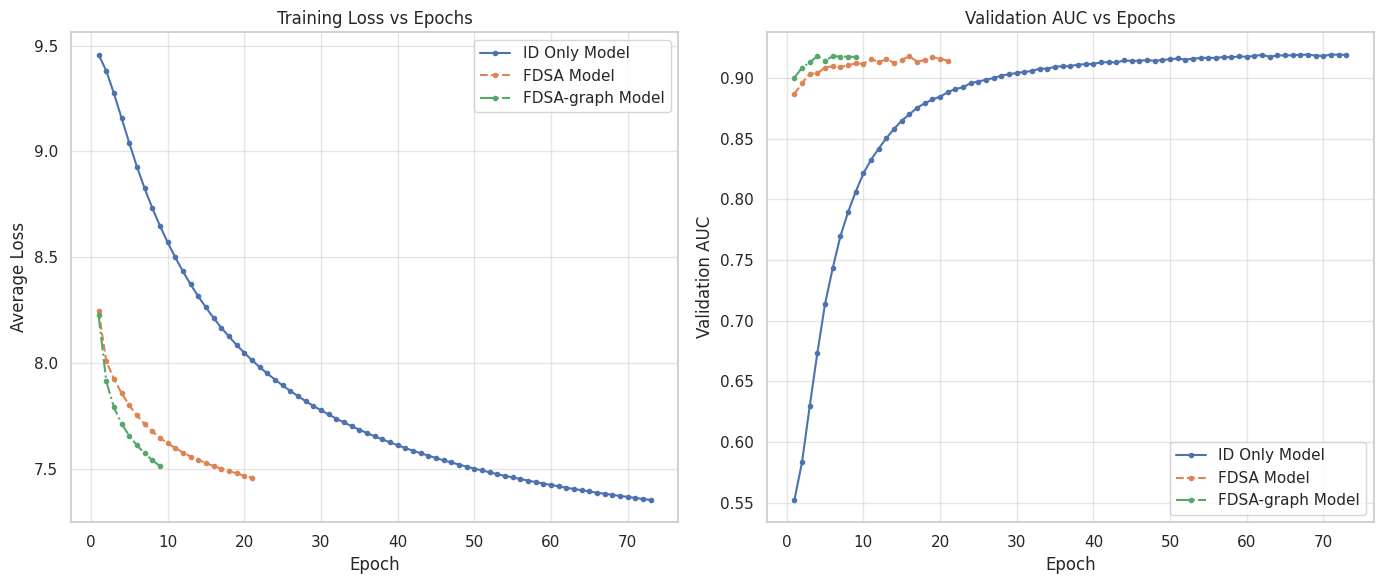

In [ ]:
import re
import matplotlib.pyplot as plt

text = """
   Batch 100/387 | Loss: 9.5056
   Batch 200/387 | Loss: 9.4727
   Batch 300/387 | Loss: 9.4297
✅ Epoch 1 | Avg Loss: 9.4572 | Val AUC: 0.5522 | Time: 32.7s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 9.3722
   Batch 200/387 | Loss: 9.3917
   Batch 300/387 | Loss: 9.3425
✅ Epoch 2 | Avg Loss: 9.3807 | Val AUC: 0.5835 | Time: 31.7s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 9.3027
   Batch 200/387 | Loss: 9.2767
   Batch 300/387 | Loss: 9.2515
✅ Epoch 3 | Avg Loss: 9.2737 | Val AUC: 0.6297 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 9.1710
   Batch 200/387 | Loss: 9.1524
   Batch 300/387 | Loss: 9.1801
✅ Epoch 4 | Avg Loss: 9.1568 | Val AUC: 0.6737 | Time: 39.9s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 9.0453
   Batch 200/387 | Loss: 9.0174
   Batch 300/387 | Loss: 9.0333
✅ Epoch 5 | Avg Loss: 9.0395 | Val AUC: 0.7140 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.9352
   Batch 200/387 | Loss: 8.9567
   Batch 300/387 | Loss: 8.9130
✅ Epoch 6 | Avg Loss: 8.9273 | Val AUC: 0.7434 | Time: 31.3s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.8374
   Batch 200/387 | Loss: 8.8211
   Batch 300/387 | Loss: 8.8280
✅ Epoch 7 | Avg Loss: 8.8250 | Val AUC: 0.7696 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.7774
   Batch 200/387 | Loss: 8.7261
   Batch 300/387 | Loss: 8.7470
✅ Epoch 8 | Avg Loss: 8.7324 | Val AUC: 0.7895 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.7331
   Batch 200/387 | Loss: 8.6374
   Batch 300/387 | Loss: 8.6689
✅ Epoch 9 | Avg Loss: 8.6480 | Val AUC: 0.8064 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.5852
   Batch 200/387 | Loss: 8.5273
   Batch 300/387 | Loss: 8.5537
✅ Epoch 10 | Avg Loss: 8.5705 | Val AUC: 0.8213 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.5759
   Batch 200/387 | Loss: 8.5179
   Batch 300/387 | Loss: 8.4542
✅ Epoch 11 | Avg Loss: 8.4990 | Val AUC: 0.8327 | Time: 40.3s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.4685
   Batch 200/387 | Loss: 8.4390
   Batch 300/387 | Loss: 8.4261
✅ Epoch 12 | Avg Loss: 8.4326 | Val AUC: 0.8419 | Time: 31.6s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.3717
   Batch 200/387 | Loss: 8.3889
   Batch 300/387 | Loss: 8.3746
✅ Epoch 13 | Avg Loss: 8.3712 | Val AUC: 0.8505 | Time: 31.6s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.2945
   Batch 200/387 | Loss: 8.3544
   Batch 300/387 | Loss: 8.2869
✅ Epoch 14 | Avg Loss: 8.3145 | Val AUC: 0.8581 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.2208
   Batch 200/387 | Loss: 8.2217
   Batch 300/387 | Loss: 8.1984
✅ Epoch 15 | Avg Loss: 8.2622 | Val AUC: 0.8649 | Time: 40.0s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.2262
   Batch 200/387 | Loss: 8.2296
   Batch 300/387 | Loss: 8.1751
✅ Epoch 16 | Avg Loss: 8.2124 | Val AUC: 0.8700 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.1985
   Batch 200/387 | Loss: 8.1862
   Batch 300/387 | Loss: 8.1445
✅ Epoch 17 | Avg Loss: 8.1666 | Val AUC: 0.8755 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.0907
   Batch 200/387 | Loss: 8.1444
   Batch 300/387 | Loss: 8.0876
✅ Epoch 18 | Avg Loss: 8.1250 | Val AUC: 0.8791 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.0752
   Batch 200/387 | Loss: 8.1249
   Batch 300/387 | Loss: 8.1022
✅ Epoch 19 | Avg Loss: 8.0851 | Val AUC: 0.8823 | Time: 31.6s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.0990
   Batch 200/387 | Loss: 8.0256
   Batch 300/387 | Loss: 8.0706
✅ Epoch 20 | Avg Loss: 8.0477 | Val AUC: 0.8847 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9938
   Batch 200/387 | Loss: 7.9438
   Batch 300/387 | Loss: 8.0496
✅ Epoch 21 | Avg Loss: 8.0128 | Val AUC: 0.8882 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.0058
   Batch 200/387 | Loss: 8.0453
   Batch 300/387 | Loss: 7.9146
✅ Epoch 22 | Avg Loss: 7.9805 | Val AUC: 0.8910 | Time: 40.0s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9636
   Batch 200/387 | Loss: 7.9129
   Batch 300/387 | Loss: 7.9369
✅ Epoch 23 | Avg Loss: 7.9500 | Val AUC: 0.8923 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9371
   Batch 200/387 | Loss: 7.9549
   Batch 300/387 | Loss: 7.8873
✅ Epoch 24 | Avg Loss: 7.9213 | Val AUC: 0.8959 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9050
   Batch 200/387 | Loss: 7.8972
   Batch 300/387 | Loss: 7.9063
✅ Epoch 25 | Avg Loss: 7.8935 | Val AUC: 0.8971 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9006
   Batch 200/387 | Loss: 7.8400
   Batch 300/387 | Loss: 7.8320
✅ Epoch 26 | Avg Loss: 7.8676 | Val AUC: 0.8986 | Time: 40.1s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.8834
   Batch 200/387 | Loss: 7.8835
   Batch 300/387 | Loss: 7.9187
✅ Epoch 27 | Avg Loss: 7.8432 | Val AUC: 0.9000 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.8408
   Batch 200/387 | Loss: 7.7530
   Batch 300/387 | Loss: 7.8249
✅ Epoch 28 | Avg Loss: 7.8192 | Val AUC: 0.9020 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7636
   Batch 200/387 | Loss: 7.8249
   Batch 300/387 | Loss: 7.7778
✅ Epoch 29 | Avg Loss: 7.7973 | Val AUC: 0.9031 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7397
   Batch 200/387 | Loss: 7.7439
   Batch 300/387 | Loss: 7.8045
✅ Epoch 30 | Avg Loss: 7.7765 | Val AUC: 0.9042 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7550
   Batch 200/387 | Loss: 7.8044
   Batch 300/387 | Loss: 7.7465
✅ Epoch 31 | Avg Loss: 7.7563 | Val AUC: 0.9050 | Time: 31.4s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7712
   Batch 200/387 | Loss: 7.7611
   Batch 300/387 | Loss: 7.7971
✅ Epoch 32 | Avg Loss: 7.7370 | Val AUC: 0.9058 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7593
   Batch 200/387 | Loss: 7.7065
   Batch 300/387 | Loss: 7.7568
✅ Epoch 33 | Avg Loss: 7.7185 | Val AUC: 0.9077 | Time: 40.0s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6877
   Batch 200/387 | Loss: 7.6975
   Batch 300/387 | Loss: 7.6443
✅ Epoch 34 | Avg Loss: 7.7014 | Val AUC: 0.9076 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.7363
   Batch 200/387 | Loss: 7.6811
   Batch 300/387 | Loss: 7.6667
✅ Epoch 35 | Avg Loss: 7.6845 | Val AUC: 0.9094 | Time: 31.3s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6750
   Batch 200/387 | Loss: 7.6235
   Batch 300/387 | Loss: 7.6851
✅ Epoch 36 | Avg Loss: 7.6686 | Val AUC: 0.9096 | Time: 31.6s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6654
   Batch 200/387 | Loss: 7.6611
   Batch 300/387 | Loss: 7.6625
✅ Epoch 37 | Avg Loss: 7.6534 | Val AUC: 0.9098 | Time: 40.1s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6026
   Batch 200/387 | Loss: 7.7245
   Batch 300/387 | Loss: 7.6191
✅ Epoch 38 | Avg Loss: 7.6384 | Val AUC: 0.9111 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6808
   Batch 200/387 | Loss: 7.5949
   Batch 300/387 | Loss: 7.6385
✅ Epoch 39 | Avg Loss: 7.6247 | Val AUC: 0.9113 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.5797
   Batch 200/387 | Loss: 7.6294
   Batch 300/387 | Loss: 7.5131
✅ Epoch 40 | Avg Loss: 7.6111 | Val AUC: 0.9117 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.5984
   Batch 200/387 | Loss: 7.6552
   Batch 300/387 | Loss: 7.6342
✅ Epoch 41 | Avg Loss: 7.5977 | Val AUC: 0.9129 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6170
   Batch 200/387 | Loss: 7.6100
   Batch 300/387 | Loss: 7.5410
✅ Epoch 42 | Avg Loss: 7.5851 | Val AUC: 0.9131 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.5949
   Batch 200/387 | Loss: 7.6186
   Batch 300/387 | Loss: 7.6066
✅ Epoch 43 | Avg Loss: 7.5733 | Val AUC: 0.9128 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5347
   Batch 200/387 | Loss: 7.5456
   Batch 300/387 | Loss: 7.5887
✅ Epoch 44 | Avg Loss: 7.5619 | Val AUC: 0.9145 | Time: 39.9s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.5988
   Batch 200/387 | Loss: 7.5479
   Batch 300/387 | Loss: 7.5009
✅ Epoch 45 | Avg Loss: 7.5507 | Val AUC: 0.9141 | Time: 31.6s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5911
   Batch 200/387 | Loss: 7.5288
   Batch 300/387 | Loss: 7.5230
✅ Epoch 46 | Avg Loss: 7.5394 | Val AUC: 0.9143 | Time: 31.8s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5080
   Batch 200/387 | Loss: 7.5009
   Batch 300/387 | Loss: 7.5594
✅ Epoch 47 | Avg Loss: 7.5298 | Val AUC: 0.9147 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.5860
   Batch 200/387 | Loss: 7.4714
   Batch 300/387 | Loss: 7.4582
✅ Epoch 48 | Avg Loss: 7.5197 | Val AUC: 0.9142 | Time: 40.2s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5723
   Batch 200/387 | Loss: 7.5268
   Batch 300/387 | Loss: 7.5291
✅ Epoch 49 | Avg Loss: 7.5099 | Val AUC: 0.9149 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4377
   Batch 200/387 | Loss: 7.4706
   Batch 300/387 | Loss: 7.4836
✅ Epoch 50 | Avg Loss: 7.5006 | Val AUC: 0.9154 | Time: 31.9s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4578
   Batch 200/387 | Loss: 7.5639
   Batch 300/387 | Loss: 7.4852
✅ Epoch 51 | Avg Loss: 7.4919 | Val AUC: 0.9161 | Time: 31.9s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.5991
   Batch 200/387 | Loss: 7.4642
   Batch 300/387 | Loss: 7.4956
✅ Epoch 52 | Avg Loss: 7.4832 | Val AUC: 0.9152 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5083
   Batch 200/387 | Loss: 7.4850
   Batch 300/387 | Loss: 7.4562
✅ Epoch 53 | Avg Loss: 7.4741 | Val AUC: 0.9160 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4853
   Batch 200/387 | Loss: 7.4523
   Batch 300/387 | Loss: 7.5086
✅ Epoch 54 | Avg Loss: 7.4659 | Val AUC: 0.9165 | Time: 40.0s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4825
   Batch 200/387 | Loss: 7.4698
   Batch 300/387 | Loss: 7.5216
✅ Epoch 55 | Avg Loss: 7.4592 | Val AUC: 0.9166 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4974
   Batch 200/387 | Loss: 7.4722
   Batch 300/387 | Loss: 7.3691
✅ Epoch 56 | Avg Loss: 7.4513 | Val AUC: 0.9166 | Time: 31.6s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4794
   Batch 200/387 | Loss: 7.4505
   Batch 300/387 | Loss: 7.4240
✅ Epoch 57 | Avg Loss: 7.4441 | Val AUC: 0.9173 | Time: 31.4s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4846
   Batch 200/387 | Loss: 7.4432
   Batch 300/387 | Loss: 7.4960
✅ Epoch 58 | Avg Loss: 7.4370 | Val AUC: 0.9171 | Time: 31.4s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4774
   Batch 200/387 | Loss: 7.3915
   Batch 300/387 | Loss: 7.4197
✅ Epoch 59 | Avg Loss: 7.4298 | Val AUC: 0.9178 | Time: 39.9s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4143
   Batch 200/387 | Loss: 7.4245
   Batch 300/387 | Loss: 7.4117
✅ Epoch 60 | Avg Loss: 7.4234 | Val AUC: 0.9175 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4335
   Batch 200/387 | Loss: 7.4286
   Batch 300/387 | Loss: 7.4322
✅ Epoch 61 | Avg Loss: 7.4169 | Val AUC: 0.9182 | Time: 31.4s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.3931
   Batch 200/387 | Loss: 7.4029
   Batch 300/387 | Loss: 7.4445
✅ Epoch 62 | Avg Loss: 7.4101 | Val AUC: 0.9191 | Time: 31.5s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4515
   Batch 200/387 | Loss: 7.3537
   Batch 300/387 | Loss: 7.4463
✅ Epoch 63 | Avg Loss: 7.4041 | Val AUC: 0.9175 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4241
   Batch 200/387 | Loss: 7.3957
   Batch 300/387 | Loss: 7.3763
✅ Epoch 64 | Avg Loss: 7.3983 | Val AUC: 0.9186 | Time: 31.4s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3951
   Batch 200/387 | Loss: 7.3455
   Batch 300/387 | Loss: 7.3927
✅ Epoch 65 | Avg Loss: 7.3926 | Val AUC: 0.9186 | Time: 40.0s
📉 AUC 未提升 | 早停计数: 3/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3926
   Batch 200/387 | Loss: 7.4231
   Batch 300/387 | Loss: 7.4281
✅ Epoch 66 | Avg Loss: 7.3865 | Val AUC: 0.9188 | Time: 31.5s
📉 AUC 未提升 | 早停计数: 4/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3388
   Batch 200/387 | Loss: 7.3978
   Batch 300/387 | Loss: 7.3811
✅ Epoch 67 | Avg Loss: 7.3815 | Val AUC: 0.9191 | Time: 31.7s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4206
   Batch 200/387 | Loss: 7.3288
   Batch 300/387 | Loss: 7.3668
✅ Epoch 68 | Avg Loss: 7.3765 | Val AUC: 0.9193 | Time: 31.8s
🌟 新纪录！保存消融模型至 best_model_id_only.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.3748
   Batch 200/387 | Loss: 7.3877
   Batch 300/387 | Loss: 7.3798
✅ Epoch 69 | Avg Loss: 7.3714 | Val AUC: 0.9185 | Time: 31.7s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3483
   Batch 200/387 | Loss: 7.4535
   Batch 300/387 | Loss: 7.3428
✅ Epoch 70 | Avg Loss: 7.3669 | Val AUC: 0.9182 | Time: 40.0s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3454
   Batch 200/387 | Loss: 7.3108
   Batch 300/387 | Loss: 7.3482
✅ Epoch 71 | Avg Loss: 7.3620 | Val AUC: 0.9193 | Time: 31.4s
📉 AUC 未提升 | 早停计数: 3/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3753
   Batch 200/387 | Loss: 7.3672
   Batch 300/387 | Loss: 7.3931
✅ Epoch 72 | Avg Loss: 7.3568 | Val AUC: 0.9193 | Time: 31.4s
📉 AUC 未提升 | 早停计数: 4/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3774
   Batch 200/387 | Loss: 7.3307
   Batch 300/387 | Loss: 7.3542
✅ Epoch 73 | Avg Loss: 7.3522 | Val AUC: 0.9190 | Time: 31.4s
📉 AUC 未提升 | 早停计数: 5/5
🛑 停止训练

🔥 启动增强版训练 (L2 Normalization + Optimized Temp)...
   Batch 100/387 | Loss: 8.2475
   Batch 200/387 | Loss: 8.1533
   Batch 300/387 | Loss: 8.1253
✅ Epoch 1 | Avg Loss: 8.2448 | Val AUC: 0.8870 | Time: 68.2s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.0348
   Batch 200/387 | Loss: 7.9627
   Batch 300/387 | Loss: 8.0211
✅ Epoch 2 | Avg Loss: 8.0070 | Val AUC: 0.8957 | Time: 67.1s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9287
   Batch 200/387 | Loss: 7.9596
   Batch 300/387 | Loss: 7.8959
✅ Epoch 3 | Avg Loss: 7.9241 | Val AUC: 0.9036 | Time: 67.2s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.8892
   Batch 200/387 | Loss: 7.8387
   Batch 300/387 | Loss: 7.8091
✅ Epoch 4 | Avg Loss: 7.8572 | Val AUC: 0.9039 | Time: 67.2s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.8148
   Batch 200/387 | Loss: 7.7344
   Batch 300/387 | Loss: 7.7704
✅ Epoch 5 | Avg Loss: 7.7995 | Val AUC: 0.9086 | Time: 67.2s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7894
   Batch 200/387 | Loss: 7.7157
   Batch 300/387 | Loss: 7.8143
✅ Epoch 6 | Avg Loss: 7.7517 | Val AUC: 0.9098 | Time: 75.7s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7323
   Batch 200/387 | Loss: 7.6862
   Batch 300/387 | Loss: 7.6665
✅ Epoch 7 | Avg Loss: 7.7111 | Val AUC: 0.9090 | Time: 67.3s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.6698
   Batch 200/387 | Loss: 7.6957
   Batch 300/387 | Loss: 7.7011
✅ Epoch 8 | Avg Loss: 7.6763 | Val AUC: 0.9106 | Time: 67.2s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6290
   Batch 200/387 | Loss: 7.7314
   Batch 300/387 | Loss: 7.6473
✅ Epoch 9 | Avg Loss: 7.6464 | Val AUC: 0.9120 | Time: 67.3s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6665
   Batch 200/387 | Loss: 7.6338
   Batch 300/387 | Loss: 7.5800
✅ Epoch 10 | Avg Loss: 7.6204 | Val AUC: 0.9119 | Time: 75.6s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5935
   Batch 200/387 | Loss: 7.6098
   Batch 300/387 | Loss: 7.5712
✅ Epoch 11 | Avg Loss: 7.5976 | Val AUC: 0.9157 | Time: 67.1s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6006
   Batch 200/387 | Loss: 7.5086
   Batch 300/387 | Loss: 7.5729
✅ Epoch 12 | Avg Loss: 7.5765 | Val AUC: 0.9133 | Time: 67.3s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5422
   Batch 200/387 | Loss: 7.5284
   Batch 300/387 | Loss: 7.5728
✅ Epoch 13 | Avg Loss: 7.5575 | Val AUC: 0.9154 | Time: 67.2s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5983
   Batch 200/387 | Loss: 7.5604
   Batch 300/387 | Loss: 7.5637
✅ Epoch 14 | Avg Loss: 7.5421 | Val AUC: 0.9127 | Time: 67.2s
📉 AUC 未提升 | 早停计数: 3/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4812
   Batch 200/387 | Loss: 7.4950
   Batch 300/387 | Loss: 7.5624
✅ Epoch 15 | Avg Loss: 7.5269 | Val AUC: 0.9149 | Time: 67.1s
📉 AUC 未提升 | 早停计数: 4/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4616
   Batch 200/387 | Loss: 7.4979
   Batch 300/387 | Loss: 7.5457
✅ Epoch 16 | Avg Loss: 7.5127 | Val AUC: 0.9179 | Time: 67.1s
🌟 新纪录！模型已保存至 best_model_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.4894
   Batch 200/387 | Loss: 7.5207
   Batch 300/387 | Loss: 7.6075
✅ Epoch 17 | Avg Loss: 7.5005 | Val AUC: 0.9135 | Time: 75.6s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4151
   Batch 200/387 | Loss: 7.4675
   Batch 300/387 | Loss: 7.4939
✅ Epoch 18 | Avg Loss: 7.4890 | Val AUC: 0.9148 | Time: 67.3s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5108
   Batch 200/387 | Loss: 7.4580
   Batch 300/387 | Loss: 7.5337
✅ Epoch 19 | Avg Loss: 7.4774 | Val AUC: 0.9171 | Time: 67.3s
📉 AUC 未提升 | 早停计数: 3/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.3841
   Batch 200/387 | Loss: 7.4659
   Batch 300/387 | Loss: 7.4795
✅ Epoch 20 | Avg Loss: 7.4667 | Val AUC: 0.9160 | Time: 67.3s
📉 AUC 未提升 | 早停计数: 4/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.4422
   Batch 200/387 | Loss: 7.4051
   Batch 300/387 | Loss: 7.4678
✅ Epoch 21 | Avg Loss: 7.4574 | Val AUC: 0.9142 | Time: 75.7s
📉 AUC 未提升 | 早停计数: 5/5
🛑 停止训练

🔥 启动终极杀手锏训练 (图谱 + 声学 + ID 三流融合)...
   Batch 100/387 | Loss: 8.2559
   Batch 200/387 | Loss: 8.1295
   Batch 300/387 | Loss: 8.0990
✅ Epoch 1 | Avg Loss: 8.2258 | Val AUC: 0.9003 | Time: 87.1s
🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9096
   Batch 200/387 | Loss: 7.8831
   Batch 300/387 | Loss: 7.8292
✅ Epoch 2 | Avg Loss: 7.9133 | Val AUC: 0.9085 | Time: 86.2s
🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.8099
   Batch 200/387 | Loss: 7.7810
   Batch 300/387 | Loss: 7.7566
✅ Epoch 3 | Avg Loss: 7.7895 | Val AUC: 0.9129 | Time: 86.2s
🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7111
   Batch 200/387 | Loss: 7.7376
   Batch 300/387 | Loss: 7.7212
✅ Epoch 4 | Avg Loss: 7.7121 | Val AUC: 0.9181 | Time: 94.7s
🌟 霸榜新纪录！保存终极模型至 best_model_graph.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.6822
   Batch 200/387 | Loss: 7.5834
   Batch 300/387 | Loss: 7.6863
✅ Epoch 5 | Avg Loss: 7.6555 | Val AUC: 0.9143 | Time: 86.2s
📉 AUC 未提升 | 早停计数: 1/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.6207
   Batch 200/387 | Loss: 7.5430
   Batch 300/387 | Loss: 7.6108
✅ Epoch 6 | Avg Loss: 7.6101 | Val AUC: 0.9180 | Time: 86.1s
📉 AUC 未提升 | 早停计数: 2/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5502
   Batch 200/387 | Loss: 7.4932
   Batch 300/387 | Loss: 7.6099
✅ Epoch 7 | Avg Loss: 7.5728 | Val AUC: 0.9176 | Time: 86.2s
📉 AUC 未提升 | 早停计数: 3/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5732
   Batch 200/387 | Loss: 7.5577
   Batch 300/387 | Loss: 7.5847
✅ Epoch 8 | Avg Loss: 7.5401 | Val AUC: 0.9177 | Time: 86.2s
📉 AUC 未提升 | 早停计数: 4/5
--------------------------------------------------
   Batch 100/387 | Loss: 7.5776
   Batch 200/387 | Loss: 7.5275
   Batch 300/387 | Loss: 7.4965
✅ Epoch 9 | Avg Loss: 7.5127 | Val AUC: 0.9173 | Time: 86.2s
"""

sections = re.split(r'🔥 启动', text)
id_only_text = sections[0]
fdsa_text = sections[1]
fdsa_graph_text = sections[2]

def extract_metrics(log_text):
    losses = []
    aucs = []
    pattern = r'Avg Loss:\s*([0-9.]+)\s*\|\s*Val AUC:\s*([0-9.]+)'
    matches = re.findall(pattern, log_text)
    for loss, auc in matches:
        losses.append(float(loss))
        aucs.append(float(auc))
    return losses, aucs

id_loss, id_auc = extract_metrics(id_only_text)
fdsa_loss, fdsa_auc = extract_metrics(fdsa_text)
graph_loss, graph_auc = extract_metrics(fdsa_graph_text)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(id_loss)+1), id_loss, label='ID Only Model', marker='.', linestyle='-')
plt.plot(range(1, len(fdsa_loss)+1), fdsa_loss, label='FDSA Model', marker='.', linestyle='--')
plt.plot(range(1, len(graph_loss)+1), graph_loss, label='FDSA-graph Model', marker='.', linestyle='-.')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.legend()
plt.grid(True, alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(id_auc)+1), id_auc, label='ID Only Model', marker='.', linestyle='-')
plt.plot(range(1, len(fdsa_auc)+1), fdsa_auc, label='FDSA Model', marker='.', linestyle='--')
plt.plot(range(1, len(graph_auc)+1), graph_auc, label='FDSA-graph Model', marker='.', linestyle='-.')
plt.title('Validation AUC vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation AUC')
plt.legend()
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig('model_comparison.png')
print(f"Extracted data counts -> ID: {len(id_loss)}, FDSA: {len(fdsa_loss)}, Graph: {len(graph_loss)}")

# 保存文件

In [ ]:
# 1. 挂载 Google Drive (如果你的文件在云端硬盘里)
from google.colab import drive
drive.mount('/content/drive')

# 2. 将当前 Notebook 转换为 HTML
# 注意：需要将 'Your_Notebook.ipynb' 替换为你实际的文件名
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/music_recommendation.ipynb"

Mounted at /content/drive
[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/Colab Notebooks/music_recommendation.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of 